# Structural aliasing in Chronos-Bolt, pure-sinusoid Bayesian analysis

**PATCHALIAS / pure-input companion to `bayesian_analysis.ipynb`.**

This notebook keeps the Bayesian workflow of the source notebook, but evaluates only the retrained
**P=16, S=16** checkpoint hosted on the project Hugging Face repository and changes the Chronos
input to **pure sinusoids only**. Every tone frequency
is constrained to the inclusive analysis band **[2, 250] Hz** at a sampling rate of 512 Hz. There
are no TSMixup or KernelSynth backgrounds and no background pseudo-replicates.

By default the run writes to
`chronos/bayesian/_run/pure_sinusoids_2_250_p16_s16_hf_230ea282/`; set
`PATCHALIASING_BAYES_ARTIFACT_ROOT` to place the same namespace on persistent storage. It cannot
reload tables or posterior traces from the mixed-background or multi-geometry analyses. Set
`PATCHALIASING_RUN_PART2=0` in a reporting-only runtime to load existing Part 2 tables without
starting Chronos collection.

## What is covered by what

| notebook section | deliverable clause | hypothesis | model |
|---|---|---|---|
| 1.2, 3.2, **4.1**, 5.2--5.3 | Local Contrast Analysis, Eq. (8)--(9) | **H1** behavioural | **A**, hierarchical Student-$t_4$ on the paired log contrast $d$ |
| 1.3, 3.2, **4.2** | Absolute Performance Analysis, Eq. (10) | **H1** representational | **B**, Gamma regression, log link, on frequency-local MDL codelength |
| 1.4, 3.2, **4.3**, 5.4 | *Phase-Invariance Analysis*, Eq. (11) | **H2** | **C**, Model A plus a per-phase-bin offset |
| 1.5, 3.2, **4.4**, 5.4 | *Site-Geometry Analysis*, Eq. (12) | **H3** location | **D1**, token-collapse profile against stride and patch grids |
| 1.5, **4.5** | *Site-Geometry Analysis*, Eq. (13) | **H3** movement | **D2**, measured site fundamental against predicted spacing |

## The five parts

0. **Setup**, repository, checkpoints, and the pure-input contract.
1. **Priors**, including predictive checks on the actual pure-input design.
2. **Observation**, Chronos runs on pure tones and writes five tidy tables. *This is the only GPU-heavy part.*
3. **Likelihood**, model factories and parameter-recovery checks.
4. **Posterior inference**, Models A, B, C, and the identifiable shared-grid form of D1.
5. **Checks**, convergence, posterior predictive checks, sensitivity, LOO, and gated verdicts.

The analysis is conditional on one pinned retrained checkpoint. With only P=S=16, overlap mitigation
(M1), between-geometry variance, separate stride-versus-patch grid effects, and movement slopes (D2)
are not identified. The notebook reports those limits explicitly instead of sampling prior-only
parameters.

## 0.1, Install

`pymc` + `arviz` are the toolkit used throughout the course labs; `chronos-forecasting` and
`torch` are needed by Part 2 only. The cell installs only what is missing, so re-running it in a
warm runtime costs nothing.

In [1]:
import importlib.util, subprocess, sys

def ensure(pkgs: dict, required: bool) -> list[str]:
    """Install the missing entries of {import_name: pip_name}. Returns what is importable after."""
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print(("installing" if required else "installing (optional)") + ":", missing)
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
        except Exception as e:
            if required:
                raise
            # Parts 1/3/4/5 do not need these; the notebook is designed to run without them.
            print(f"  optional install failed ({e}); continuing without it")
    return [mod for mod in pkgs if importlib.util.find_spec(mod) is not None]

# Required everywhere: the Bayesian machinery and the parquet checkpoint format.
ensure({"pymc": "pymc", "arviz": "arviz", "pyarrow": "pyarrow"}, required=True)

# Part 2 only: loading Chronos and running it. Deliberately optional, so that a CPU runtime can
# run Parts 1/3/4/5 against tables a previous GPU run already wrote.
have = ensure({"torch": "torch", "chronos": "chronos-forecasting"}, required=False)
HAVE_TORCH = "torch" in have and "chronos" in have
print({"Part 2 packages available": HAVE_TORCH})
if HAVE_TORCH:
    import torch
    print({"CUDA available": bool(torch.cuda.is_available())})
else:
    print("  -> switch to a GPU runtime for Part 2, or point Part 0.3 at checkpoints that "
          "already contain its tables.")

{'Part 2 packages available': True}
{'CUDA available': False}


## 0.2, Repository

`probe_lib.py` and `collect.py` live in `chronos/bayesian/` of the project repository, next to this
notebook. The cell below locates the repository root by walking up from the current working
directory; if the repository is not found, it clones it.

In [2]:
import os, sys
from pathlib import Path

REPO_URL = "https://github.com/FedericoSabbadini/patchAliasing.git"

MARKER = Path("chronos") / "bayesian" / "probe_lib.py"

def find_repo() -> Path:
    """Locate the repository root by walking up from the current working directory."""
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / MARKER).exists():
            return cand

    # If not found locally, clone the repository
    target = here / "patchAliasing"
    if not (target / MARKER).exists():
        import subprocess
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(target)])

    if not (target / MARKER).exists():
        raise FileNotFoundError(
            f"{MARKER} is missing from {target}.\n"
            f"The analysis modules have to be on the branch {REPO_URL} clones (its default "
            f"branch). Either push them, or upload probe_lib.py and collect.py by hand:\n"
            f"then place them in {target / 'chronos' / 'bayesian'}.")
    return target

REPO = find_repo()
BAYES_DIR = REPO / "chronos" / "bayesian"
sys.path.insert(0, str(BAYES_DIR))       # so `import probe_lib` / `import collect` resolve
print("repository :", REPO)
print("modules    :", BAYES_DIR)

repository : c:\Users\bonio\dev\patchAliasing
modules    : c:\Users\bonio\dev\patchAliasing\chronos\bayesian


## 0.3, Imports, seed, checkpoints

Checkpoints are stored locally under `CKPT_DIR`. Each part writes its results to disk, so an
interrupted run can resume from the last completed stage without altering the statistical design.

In [3]:
from __future__ import annotations

import json, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import arviz as az
import pymc as pm
from scipy import stats

warnings.filterwarnings("default")
az.style.use("arviz-whitegrid")

# ---- reproducibility: one seed for python, numpy and every PyMC sampler call ----------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

# ---- sampling configuration -----------------------------------------------------------
RESUME = True                 # reload a part from its checkpoint instead of recomputing it
RUN_PART2 = os.environ.get("PATCHALIASING_RUN_PART2", "1").strip().lower() not in {"0", "false", "no"}

DRAWS, TUNE, CHAINS = (2000, 2000, 4)
TARGET_ACCEPT = 0.9

# ---- who runs NUTS ---------------------------------------------------------------------
# This setting changes only the sampler implementation; it does not change the model.
#   "pymc"     default, CPU only, slowest
#   "nutpie"   Rust, same CPU, typically several times faster
NUTS_BACKEND = "pymc"

if NUTS_BACKEND != "pymc":
    import importlib.util, subprocess
    _pkg = {"numpyro": "numpyro", "nutpie": "nutpie"}[NUTS_BACKEND]
    if importlib.util.find_spec(_pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pkg])
    if NUTS_BACKEND == "numpyro":
        import jax
        print("JAX devices:", jax.devices())
print(f"NUTS backend: {NUTS_BACKEND}")

# ---- checkpoints ----------------------------------------------------------------------
# All intermediate results (MCMC traces as NetCDF, collected data as Parquet, figures as
# PNG) are written to CKPT_DIR. A completed stage is reloaded rather than recomputed, so
# an interrupted run resumes from the last completed stage.
_artifact_root = os.environ.get("PATCHALIASING_BAYES_ARTIFACT_ROOT", "").strip()
_root = Path(_artifact_root).expanduser() if _artifact_root else BAYES_DIR

CKPT_DIR = _root / "_run" / "pure_sinusoids_2_250_p16_s16_hf_230ea282"
DATA_DIR = CKPT_DIR / "data"          # Part 2 tidy tables (and its per-model shards)
FIG_DIR = CKPT_DIR / "figures"
for d in (CKPT_DIR, DATA_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

def banner(part: str) -> None:
    """Print a section separator for the notebook run log."""
    print("=" * 78); print(part); print("=" * 78)

# ---- checkpoint helpers ----------------------------------------------------------------

def ckpt(name: str) -> Path:
    """Return the full path for a checkpoint file given its short name."""
    return CKPT_DIR / (name)

def have(name: str) -> bool:
    """Check whether a checkpoint file already exists (and RESUME is enabled)."""
    return RESUME and ckpt(name).exists()

def save_idata(idata, name: str):
    """Write an ArviZ InferenceData object to NetCDF."""
    idata.to_netcdf(str(ckpt(name)));  print(f"  checkpoint -> {ckpt(name).name}");  return idata

def load_idata(name: str):
    """Reload an ArviZ InferenceData object from a NetCDF checkpoint."""
    print(f"  checkpoint <- {ckpt(name).name}");  return az.from_netcdf(str(ckpt(name)))

def save_df(df: pd.DataFrame, name: str):
    """Write a DataFrame to Parquet."""
    out = df.copy()
    out.to_parquet(ckpt(name), index=False);  print(f"  checkpoint -> {ckpt(name).name}");  return df

def load_df(name: str) -> pd.DataFrame:
    """Reload a DataFrame from a Parquet checkpoint."""
    df = pd.read_parquet(ckpt(name))
    print(f"  checkpoint <- {ckpt(name).name}")
    return df

def cached_fit(name: str, build_and_sample):
    """Sample a model, or reload it if this part already ran. The unit of resumption is one model."""
    if have(name):
        return load_idata(name)
    return save_idata(build_and_sample(), name)

print(f"checkpoints : {CKPT_DIR}")
print(f"draws={DRAWS} tune={TUNE} chains={CHAINS}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


NUTS backend: pymc
checkpoints : c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\pure_sinusoids_2_250_p16_s16_hf_230ea282
draws=2000 tune=2000 chains=4


## 0.4, Experimental-design constants and pure-input contract

`probe_lib` remains the single source of truth for sampling rate, context length, and lock
geometry. This notebook explicitly pins the sole target geometry and Hugging Face revision.
$\mathcal F_{lock}=\{c f_s/S\}\cup\{k f_s/P\}$. This companion notebook then applies a narrow input
adapter: no background generator, unit-amplitude pure tones, inclusive band [2, 250] Hz, and
uniformly spaced unique starting phases.

In [4]:
import probe_lib as pl

PURE_BAND = (2.0, 250.0)
PURE_GENERATORS = ("pure",)
TARGET_MODELS = ((16, 16),)
TARGET_HF_REPO = "federicosabbadini/patch-aliasing-models"
TARGET_HF_SUBFOLDER = "p16-s16-seed42"
TARGET_HF_REVISION = "230ea28278a3c60621964b920e9778c0ba73337e"

assert tuple(map(float, pl.BAND)) == PURE_BAND, (
    f"probe_lib.BAND changed to {pl.BAND}; review the pure-input contract before running")

def pure_phases(_frequency: float, n_max: int = 10) -> np.ndarray:
    """Exactly `n_max` unique initial phases for a pure sinusoid."""
    if n_max < 1:
        raise ValueError("n_max must be positive")
    return np.linspace(0.0, 2.0 * np.pi, int(n_max), endpoint=False, dtype=float)

print(f"fs = {pl.FS} Hz    context = {pl.CTX} samples    horizon = {pl.PRED}")
print(f"input = unit-amplitude pure sinusoids    inclusive band = {PURE_BAND} Hz")
print(f"target checkpoint = {TARGET_HF_REPO}/{TARGET_HF_SUBFOLDER}")
print(f"pinned HF revision = {TARGET_HF_REVISION}")

rows = []
for (P, S) in TARGET_MODELS:
    offs = {f: pl.control_offset(P, S, f) for f in pl.f_lock(P, S)}
    locks = list(offs)
    clean = [f for f, d in offs.items() if np.isfinite(d)]
    used = [offs[f] for f in clean]
    n_so = sum(pl.lock_family(f, P, S) == "stride" for f in locks)
    rows.append(dict(model=pl.model_tag(P, S), P=P, S=S, overlap=(P - S) / P,
                     delta_Hz=("-" if not used else f"{min(used):.2f}"
                               if len(set(np.round(used, 6))) == 1
                               else f"{min(used):.2f}-{max(used):.2f}"),
                     n_lock=len(locks), n_usable=len(clean), stride_only=n_so,
                     stride_locks=", ".join(f"{x:g}" for x in pl.stride_locks(S)[:4]) + " ...",
                     patch_nulls=", ".join(f"{x:g}" for x in pl.patch_nulls(P)[:4]) + " ..."))
design = pd.DataFrame(rows)
display(design)

print("\nn_usable < n_lock means that no admissible paired-control offset stays clear of both "
      "grids; that site is dropped rather than compared with another lock.")
print(f"stride-only sites in the current configured design: {int(design['stride_only'].sum())}")
print("\nSingle-checkpoint limitations:")
print("  - M1 and between-geometry variance are not identified.")
print("  - P=S=16 makes stride and patch grids identical; D1 tests their shared grid only.")
print("  - D2 movement slopes need multiple spacings and are not identified.")


fs = 512 Hz    context = 480 samples    horizon = 64
input = unit-amplitude pure sinusoids    inclusive band = (2.0, 250.0) Hz
target checkpoint = federicosabbadini/patch-aliasing-models/p16-s16-seed42
pinned HF revision = 230ea28278a3c60621964b920e9778c0ba73337e


,model,P,S,overlap,delta_Hz,n_lock,n_usable,stride_only,stride_locks,patch_nulls
0,p16-s16,16,16,0.0,8.00,7,7,0,"32, 64, 96, 128 ...","32, 64, 96, 128 ..."



n_usable < n_lock means that no admissible paired-control offset stays clear of both grids; that site is dropped rather than compared with another lock.
stride-only sites in the current configured design: 0

Single-checkpoint limitations:
  - M1 and between-geometry variance are not identified.
  - P=S=16 makes stride and patch grids identical; D1 tests their shared grid only.
  - D2 movement slopes need multiple spacings and are not identified.


---
# Part 1, Priors

The deliverable's Bayesian section names a prior for every parameter. This part does two things
with them, **before any observation exists**:

1. writes them down in one table, so the reported analysis and the document cannot drift apart;
2. checks what they *imply*. A prior is not weakly informative because it is labelled weakly
   informative, it is weakly informative if the data it predicts are plausible and if it does not
   quietly assert the conclusion. We therefore push each prior through its own likelihood and look
   at the resulting distribution of the quantities we care about: the recovery ratio $e^{\bar\beta}$,
   the codelength ratio $e^{\theta_{lock}}$, the shape of a collapse comb.

Nothing here needs Chronos: the *design* (which geometries, which lock sites, which phases) is
fixed in advance by `probe_lib`, and only the responses are unknown. That is precisely what makes a
genuine prior predictive check possible.

In [5]:
banner("PART 1, PRIORS")

# Prior scales are preregistered here, including the sensitivity ladder used in Part 5.
PRIOR_SCALE = 0.5                       # the deliverable's primary choice
PRIOR_LADDER = [0.25, 0.5, 1.0]         # sceptical / primary / wide, for the sensitivity refits
NU = 4                                  # Student-t degrees of freedom, as written in the .tex

# Decision thresholds, preregistered so they cannot be chosen after seeing the posterior.
ATTENUATION_20 = np.log(0.8)            # "at least 20% attenuation"  ->  beta < log 0.8
ROPE_LOG = np.log(1.1)                  # practical equivalence: a +/-10% effect is no effect
ROPE_SLOPE = 0.1                        # H3a / H3b movement: |kappa_F - 1| < 0.1

PRIOR_SPEC = pd.DataFrame([
    # model, parameter, prior, role, where it is written in the deliverable
    ("A/C", "beta_bar",      f"StudentT(nu=4, 0, {PRIOR_SCALE})",  "population phase-lock effect on log-recovery", "Eq. (9)"),
    ("A/C", "sigma_harm",    f"HalfStudentT(nu=4, {PRIOR_SCALE})", "spread across lock harmonics", "Eq. (9)"),
    ("A/C", "sigma",         f"HalfStudentT(nu=4, {PRIOR_SCALE})", "residual scale of the contrast", "Eq. (9)"),
    ("C",   "sigma_phase",   "HalfNormal(0.25)",                   "spread of the per-phase offsets (8 phase bins)", "Eq. (11)"),
    ("B",   "alpha_0",       "Normal(log(40), 1)",                  "baseline log codelength for an 80-example cell", "Eq. (10)"),
    ("B",   "theta_lock",    "Normal(0, 0.5)",                     "log codelength expansion at a lock", "Eq. (10)"),
    ("B",   "k (shape)",     "Gamma(2, 0.1)",                      "Gamma dispersion", "Eq. (10)"),
    ("D1",  "alpha_g",       "Normal(0, 1)",                       "off-grid level of log z_g", "Eq. (12)"),
    ("D1",  "theta_B",       "Normal(0, 1)",                       "dip on the shared fs/16 grid; H3 predicts < 0", "Eq. (12)"),
    ("D1",  "sigma",         "HalfNormal(1)",                      "residual scale", "Eq. (12)"),
], columns=["model", "parameter", "prior", "role", "deliverable"])
display(PRIOR_SPEC)

PART 1, PRIORS


,model,parameter,prior,role,deliverable
0,A/C,beta_bar,"StudentT(nu=4, 0, 0.5)",population phase-lock effect on log-recovery,Eq. (9)
1,A/C,sigma_harm,"HalfStudentT(nu=4, 0.5)",spread across lock harmonics,Eq. (9)
2,A/C,sigma,"HalfStudentT(nu=4, 0.5)",residual scale of the contrast,Eq. (9)
3,C,sigma_phase,HalfNormal(0.25),spread of the per-phase offsets (8 phase bins),Eq. (11)
4,B,alpha_0,"Normal(log(40), 1)",baseline log codelength for an 80-example cell,Eq. (10)
5,B,theta_lock,"Normal(0, 0.5)",log codelength expansion at a lock,Eq. (10)
6,B,k (shape),"Gamma(2, 0.1)",Gamma dispersion,Eq. (10)
7,D1,alpha_g,"Normal(0, 1)",off-grid level of log z_g,Eq. (12)
8,D1,theta_B,"Normal(0, 1)",dip on the shared fs/16 grid; H3 predicts < 0,Eq. (12)
9,D1,sigma,HalfNormal(1),residual scale,Eq. (12)


## 1.1, The pure-input design skeleton

The geometries, lock sites, and phases are fixed by the design. With a pure sinusoid there is no
background draw to repeat: every row is identified by geometry, lock frequency, and one unique
initial phase. Building that skeleton now makes the prior predictive use exactly the rows Part 2
will later populate.

In [6]:
def design_skeleton(n_phase: int = 10) -> pd.DataFrame:
    """One row per (geometry, usable lock site, unique pure-tone phase)."""
    rows = []
    for (P, S) in TARGET_MODELS:
        offsets = {f: pl.control_offset(P, S, f) for f in pl.f_lock(P, S)}
        for f_lock in [f for f, delta in offsets.items() if np.isfinite(delta)]:
            for phase_idx, phase in enumerate(pure_phases(f_lock, n_phase)):
                rows.append(dict(model=pl.model_tag(P, S), P=P, S=S,
                                 overlap=(P - S) / P, f_lock=f_lock,
                                 family=pl.lock_family(f_lock, P, S),
                                 generator="pure", bg_id=0,
                                 phase_idx=phase_idx, phase=float(phase)))
    return pd.DataFrame(rows)

SKELETON = design_skeleton(n_phase=10)
print(f"planned pure contrast observations: {len(SKELETON)}")
display(SKELETON.groupby("model").agg(rows=("f_lock", "size"),
                                      locks=("f_lock", "nunique"),
                                      phases=("phase_idx", "nunique")))


planned pure contrast observations: 70


,rows,locks,phases
model,,,
p16-s16,70,7,10


## 1.2, Prior predictive for Models A and C (H1 behavioural, H2)

The contrast $d$ lives on a log-ratio scale, so $\bar\beta$ is read as $e^{\bar\beta}$: the
multiplicative change in forecast amplitude recovery at a lock relative to its controls. The
question a prior predictive answers is whether $\text{Student-}t_4(0, 0.5)$ describes *ignorance*
about that ratio or a belief about it.

Three things are checked:

* the prior is symmetric, so it does not favour attenuation over amplification; its scale and
  hierarchy can still influence the posterior and are checked again in Part 5;
* it reaches far enough, a scale of $0.5$ puts $e^{\pm 0.5}\approx 1.65$ at one scale unit and the
  heavy $t_4$ tails admit far larger effects, so a real strong effect will not be shrunk away;
* the simulated contrasts $d$ are on the same order as contrasts that could physically occur
  (recovery ratios are bounded below by 0 and rarely exceed a few).

C:\Users\bonio\AppData\Local\Temp\ipykernel_29268\772185913.py:38: UserWarning: The figure layout has changed to tight
  fig.tight_layout(); fig.savefig(FIG_DIR / "P1_prior_predictive_contrast.png", dpi=140,


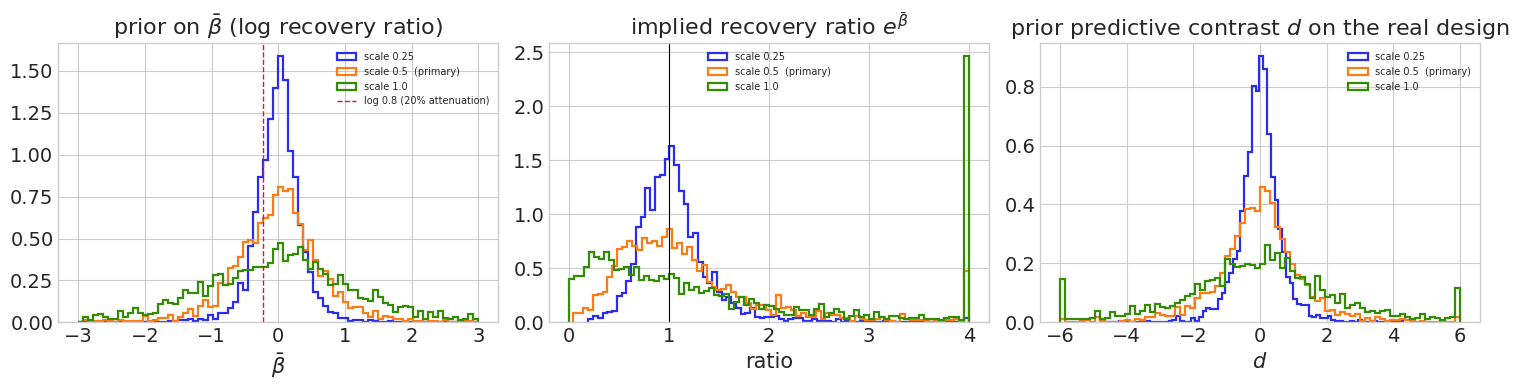

under the primary prior (scale 0.5):
  P(beta_bar < 0)                 = 0.500   <- 0.5 means symmetric: the prior does not favour the hypothesis
  P(>=20% attenuation) a priori   = 0.336
  P(>=50% attenuation) a priori   = 0.122   <- reachable, so a real strong effect will not be shrunk away
  central 95% of the ratio        = [0.25, 4.03]


In [7]:
def simulate_contrast_prior(skeleton: pd.DataFrame, scale: float, n_draw: int = 2000,
                            rng=None) -> dict:
    """Draw parameters from the Model A prior and push them through the likelihood.

    Returns both the population-level effect draws and simulated contrasts on the real design, so
    the prior can be judged on the data it predicts rather than on its own parameters.
    """
    rng = rng or np.random.default_rng(SEED)

    # priors, exactly as tabulated above
    beta_bar = stats.t.rvs(NU, scale=scale, size=n_draw, random_state=rng.integers(1 << 31))
    half = lambda: np.abs(stats.t.rvs(NU, scale=scale, size=n_draw,
                                      random_state=rng.integers(1 << 31)))
    sig_h, sigma = half(), half()

    # one simulated dataset per draw would be huge; simulate a random design row per draw instead,
    # which gives the marginal prior predictive of a single observation
    i = rng.integers(0, len(skeleton), n_draw)
    mu = beta_bar + sig_h * rng.normal(size=n_draw)
    d = mu + sigma * stats.t.rvs(NU, size=n_draw, random_state=rng.integers(1 << 31))
    return dict(beta_bar=beta_bar, d=d, ratio=np.exp(beta_bar))


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for scale in PRIOR_LADDER:
    sim = simulate_contrast_prior(SKELETON, scale)
    lbl = f"scale {scale}" + ("  (primary)" if scale == PRIOR_SCALE else "")
    axes[0].hist(sim["beta_bar"], bins=80, range=(-3, 3), histtype="step", lw=1.6, label=lbl, density=True)
    axes[1].hist(np.clip(sim["ratio"], 0, 4), bins=80, histtype="step", lw=1.6, label=lbl, density=True)
    axes[2].hist(np.clip(sim["d"], -6, 6), bins=80, histtype="step", lw=1.6, label=lbl, density=True)

axes[0].axvline(ATTENUATION_20, color="crimson", ls="--", lw=1, label="log 0.8 (20% attenuation)")
axes[0].set_title(r"prior on $\bar\beta$ (log recovery ratio)"); axes[0].set_xlabel(r"$\bar\beta$")
axes[1].axvline(1.0, color="k", lw=0.8)
axes[1].set_title(r"implied recovery ratio $e^{\bar\beta}$"); axes[1].set_xlabel("ratio")
axes[2].set_title("prior predictive contrast $d$ on the real design"); axes[2].set_xlabel("$d$")
for a in axes: a.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG_DIR / "P1_prior_predictive_contrast.png", dpi=140,
                                bbox_inches="tight"); plt.show()

sim = simulate_contrast_prior(SKELETON, PRIOR_SCALE, n_draw=20000)
print(f"under the primary prior (scale {PRIOR_SCALE}):")
print(f"  P(beta_bar < 0)                 = {np.mean(sim['beta_bar'] < 0):.3f}   <- 0.5 means symmetric: "
      f"the prior does not favour the hypothesis")
print(f"  P(>=20% attenuation) a priori   = {np.mean(sim['beta_bar'] < ATTENUATION_20):.3f}")
print(f"  P(>=50% attenuation) a priori   = {np.mean(sim['beta_bar'] < np.log(0.5)):.3f}   <- reachable, "
      f"so a real strong effect will not be shrunk away")
print(f"  central 95% of the ratio        = [{np.exp(np.quantile(sim['beta_bar'], .025)):.2f}, "
      f"{np.exp(np.quantile(sim['beta_bar'], .975)):.2f}]")

### The H2 phase term

Model C cuts the phase circle into eight equal slices and gives each its own offset. The estimand
$\sigma_\phi$ is the spread of those offsets: how much the lock deficit moves as the signal slides
through its cycle. Its prior, $\text{Half-}\mathcal N(0,0.25)$, puts mass on both sides of the
equivalence boundary $\log 1.1$, so the H2 verdict is decided by the data rather than by the prior.

C:\Users\bonio\AppData\Local\Temp\ipykernel_29268\823692667.py:17: UserWarning: The figure layout has changed to tight
  fig.tight_layout(); fig.savefig(FIG_DIR / "P1_prior_predictive_phase.png", dpi=140,


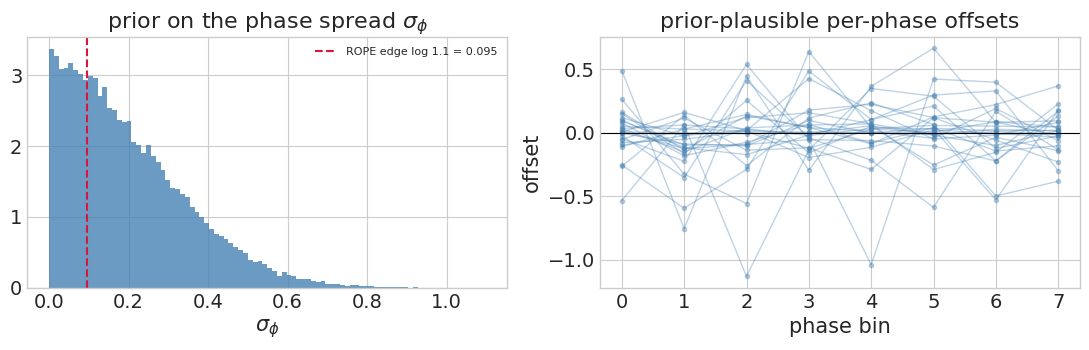

P(sigma_phase < ROPE) a priori = 0.299   <- mass on both sides; posterior and sensitivity checks still determine the verdict


In [8]:
sigma_phase_prior = np.abs(RNG.normal(0, 0.25, 40000))     # Half-Normal(0.25)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(sigma_phase_prior, bins=90, density=True, color="steelblue", alpha=.8)
ax[0].axvline(ROPE_LOG, color="crimson", ls="--", label=f"ROPE edge log 1.1 = {ROPE_LOG:.3f}")
ax[0].set_title(r"prior on the phase spread $\sigma_\phi$"); ax[0].legend(fontsize=8)
ax[0].set_xlabel(r"$\sigma_\phi$")

# what a prior-plausible set of per-phase offsets looks like
for _ in range(25):
    ax[1].plot(np.arange(N_PHASE_BINS := 8),
               RNG.choice(sigma_phase_prior) * RNG.normal(size=8),
               marker="o", ms=3, alpha=.35, lw=1, color="steelblue")
ax[1].axhline(0, color="k", lw=.8)
ax[1].set_xlabel("phase bin"); ax[1].set_ylabel("offset")
ax[1].set_title("prior-plausible per-phase offsets")
fig.tight_layout(); fig.savefig(FIG_DIR / "P1_prior_predictive_phase.png", dpi=140,
                                bbox_inches="tight"); plt.show()

print(f"P(sigma_phase < ROPE) a priori = {np.mean(sigma_phase_prior < ROPE_LOG):.3f}   "
      f"<- mass on both sides; posterior and sensitivity checks still determine the verdict")

## 1.3, Prior predictive for Model B (H1 representational)

The response is a prequential codelength in bits: strictly positive, right-skewed, and with a
variance that grows with its mean. That is what the Gamma likelihood with a log link is for, and it
is why $\theta_{lock}$ is read multiplicatively, $e^{\theta_{lock}}$ is the factor by which
describing the labels costs more at a locked frequency.

C:\Users\bonio\AppData\Local\Temp\ipykernel_29268\1847691074.py:14: UserWarning: The figure layout has changed to tight
  fig.tight_layout(); fig.savefig(FIG_DIR / "P1_prior_predictive_codelength.png", dpi=140,


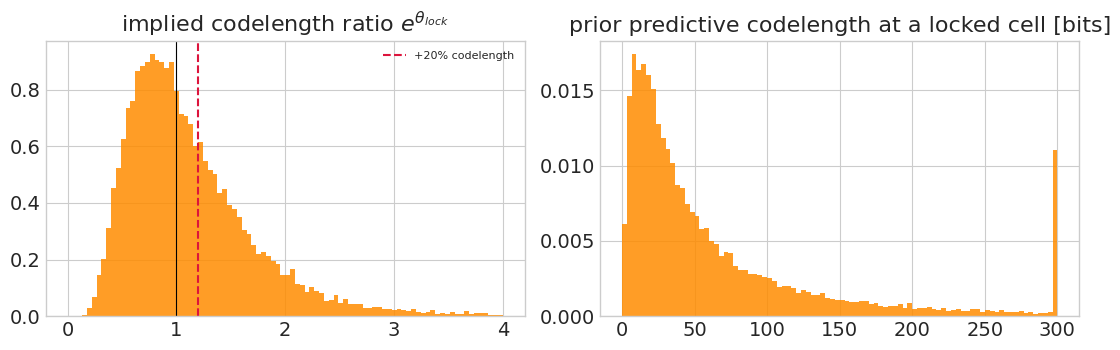

P(theta_lock > 0) a priori          = 0.494   <- symmetric
P(codelength expands by >=20%)      = 0.357
prior predictive codelength median  = 37.3 bits (95% CI 3.8-361.2) -- positive and right-skewed, as a codelength must be


In [9]:
n = 20000
alpha0_p = RNG.normal(np.log(40.0), 1.0, n)      # 40 bits is a plausible baseline for a 80-example cell
theta_p = RNG.normal(0.0, 0.5, n)                # Eq. (10) prior
k_p = RNG.gamma(2.0, 1 / 0.1, n)                 # Gamma(2, rate=0.1): mean 20, wide
mu_locked = np.exp(alpha0_p + theta_p)
y_locked = RNG.gamma(k_p, mu_locked / k_p)       # PyMC's (alpha=k, beta=k/mu) parameterisation

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(np.exp(theta_p), bins=90, range=(0, 4), density=True, color="darkorange", alpha=.85)
ax[0].axvline(1, color="k", lw=.8); ax[0].axvline(1.2, color="crimson", ls="--", label="+20% codelength")
ax[0].set_title(r"implied codelength ratio $e^{\theta_{lock}}$"); ax[0].legend(fontsize=8)
ax[1].hist(np.clip(y_locked, 0, 300), bins=90, density=True, color="darkorange", alpha=.85)
ax[1].set_title("prior predictive codelength at a locked cell [bits]")
fig.tight_layout(); fig.savefig(FIG_DIR / "P1_prior_predictive_codelength.png", dpi=140,
                                bbox_inches="tight"); plt.show()

print(f"P(theta_lock > 0) a priori          = {np.mean(theta_p > 0):.3f}   <- symmetric")
print(f"P(codelength expands by >=20%)      = {np.mean(theta_p > np.log(1.2)):.3f}")
print(f"prior predictive codelength median  = {np.median(y_locked):.1f} bits "
      f"(95% CI {np.quantile(y_locked, .025):.1f}-{np.quantile(y_locked, .975):.1f}) "
      f"-- positive and right-skewed, as a codelength must be")

## 1.4, Prior predictive for the identified D1 shared-grid effect (H3)

D1 asks whether token dispersion is lower on the shared $f_s/16$ grid than off it. Its one
identified coefficient has a symmetric $\mathcal N(0,1)$ prior, so a dip is not assumed. D2 has
no prior predictive here because one geometry supplies no movement axis and D2 is not fitted.

C:\Users\bonio\AppData\Local\Temp\ipykernel_29268\3706517702.py:7: UserWarning: The figure layout has changed to tight
  fig.tight_layout(); fig.savefig(FIG_DIR / "P1_prior_predictive_H3.png", dpi=140,


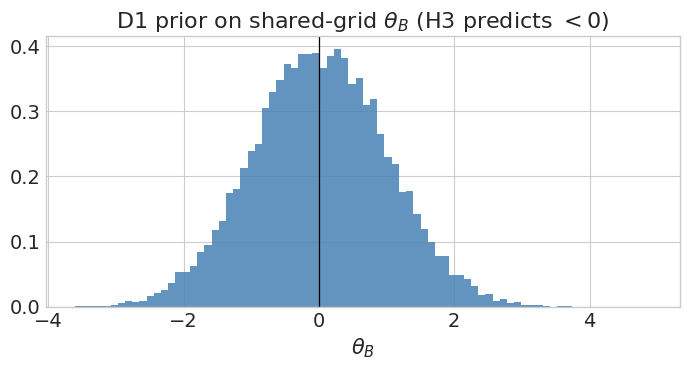

P(theta_B < 0) a priori = 0.496 <- symmetric


In [10]:
fig, ax = plt.subplots(figsize=(7, 3.8))
theta_B = RNG.normal(0, 1, 20000)
ax.hist(theta_B, bins=80, density=True, color="steelblue", alpha=.85)
ax.axvline(0, color="k", lw=.9)
ax.set_title(r"D1 prior on shared-grid $\theta_B$ (H3 predicts $<0$)")
ax.set_xlabel(r"$\theta_B$")
fig.tight_layout(); fig.savefig(FIG_DIR / "P1_prior_predictive_H3.png", dpi=140,
                                bbox_inches="tight"); plt.show()
print(f"P(theta_B < 0) a priori = {np.mean(theta_B < 0):.3f} <- symmetric")

## 1.5, Checkpoint

The prior specification and its predictive summaries are stored so the reported analysis can be
traced back to priors that were fixed before the data existed.

In [11]:
prior_summary = dict(
    prior_scale=PRIOR_SCALE, prior_ladder=PRIOR_LADDER, nu=NU,
    attenuation_20=float(ATTENUATION_20), rope_log=float(ROPE_LOG), rope_slope=ROPE_SLOPE,
    p_attenuation20_prior=float(np.mean(sim["beta_bar"] < ATTENUATION_20)),
    p_sigma_phase_in_rope_prior=float(np.mean(sigma_phase_prior < ROPE_LOG)),
    planned_contrast_rows=int(len(SKELETON)), seed=SEED,
    target_models=[list(x) for x in TARGET_MODELS], hf_repo=TARGET_HF_REPO,
    hf_subfolder=TARGET_HF_SUBFOLDER, hf_revision=TARGET_HF_REVISION,
)
(ckpt("01_prior_spec.json")).write_text(json.dumps(prior_summary, indent=2))
save_df(PRIOR_SPEC, "01_prior_spec.parquet")
print(json.dumps(prior_summary, indent=2))

  checkpoint -> 01_prior_spec.parquet
{
  "prior_scale": 0.5,
  "prior_ladder": [
    0.25,
    0.5,
    1.0
  ],
  "nu": 4,
  "attenuation_20": -0.2231435513142097,
  "rope_log": 0.09531017980432493,
  "rope_slope": 0.1,
  "p_attenuation20_prior": 0.33585,
  "p_sigma_phase_in_rope_prior": 0.2987,
  "planned_contrast_rows": 70,
  "seed": 42,
  "target_models": [
    [
      16,
      16
    ]
  ],
  "hf_repo": "federicosabbadini/patch-aliasing-models",
  "hf_subfolder": "p16-s16-seed42",
  "hf_revision": "230ea28278a3c60621964b920e9778c0ba73337e"
}


---
# Part 2, Observation: Chronos on pure sinusoids

This is the only part that loads a Chronos model. `collect.py` still supplies the table-building
logic, while the input adapter in the next cell supplies `None` as the background so
`probe_lib.build_context` emits a unit-amplitude pure tone. All actual frequencies are checked
against the inclusive [2, 250] Hz contract.

| table | pure-input measurement | role |
|---|---|---|
| `contrasts` | recovery at each lock and its two matched controls, sharing one initial phase | H1 behavioural and H2 |
| `mdl_cells` | codelength for separating $f_c-1$ from $f_c+1$ Hz; edge centres are excluded so both tones stay in-band | H1 representational |
| `mdl_bandtasks` | seven band tasks on the pure-tone sweep | descriptive cross-check |
| `collapse` | token dispersion on the union grid, pure mode only | H3 location |
| `sites` | detected pure-mode collapse sites and derived spacing summaries | descriptive H3 movement check |

Pure phases are sampled uniformly on $[0,2\pi)$ and are unique. The MDL cells use 40 phases per
class, so every cell has the same 80 examples without duplicating a nonexistent background.

Checkpoints are sharded per geometry inside the pure-only namespace. Existing mixed-background
shards and traces are never visible to this run.

In [12]:
banner("PART 2, OBSERVATION (Chronos, PURE SINUSOIDS)")

import collect
import hashlib

def load_target_hf_checkpoint(P: int, S: int, device: str = "cpu", pipeline_cls=None):
    """Load only the pinned project checkpoint; never substitute stock or local weights."""
    if (int(P), int(S)) not in TARGET_MODELS:
        raise ValueError(f"this notebook is pinned to {TARGET_MODELS}, got {(P, S)}")
    if pipeline_cls is None:
        from chronos import BaseChronosPipeline as pipeline_cls
    pipe = pipeline_cls.from_pretrained(
        TARGET_HF_REPO, subfolder=TARGET_HF_SUBFOLDER,
        revision=TARGET_HF_REVISION, device_map=device)
    label = (f"p{P}-s{S} (HF {TARGET_HF_REPO}/{TARGET_HF_SUBFOLDER}"
             f"@{TARGET_HF_REVISION[:8]})")
    return pipe, label

def pure_background_pool(generator: str, n_bg: int, length: int = pl.CTX + pl.PRED,
                         seed0: int = 10_000) -> list[None]:
    """Compatibility adapter: a pure signal has no background realisation."""
    if generator != "pure":
        raise ValueError(f"pure notebook received unexpected generator {generator!r}")
    if n_bg < 1:
        raise ValueError("n_bg must be positive")
    return [None] * int(n_bg)

def save_pure_signal_pool(out_dir, generators=PURE_GENERATORS, n_bg: int = 1,
                          seed0: int = 10_000) -> pd.DataFrame:
    """Archive the deterministic input contract plus three reloadable example tones."""
    if tuple(generators) != PURE_GENERATORS:
        raise ValueError(f"expected generators={PURE_GENERATORS}, got {generators}")
    out = Path(out_dir) / "signals"
    out.mkdir(parents=True, exist_ok=True)
    spec = dict(mode="pure_sinusoid", band_hz=list(PURE_BAND), band_inclusive=True,
                sampling_rate_hz=pl.FS, context_samples=pl.CTX,
                horizon_samples=pl.PRED, amplitude=1.0,
                phase_rule="uniform unique phases on [0, 2*pi)",
                models=[pl.model_tag(P, S) for P, S in TARGET_MODELS],
                hf_repo=TARGET_HF_REPO, hf_subfolder=TARGET_HF_SUBFOLDER,
                hf_revision=TARGET_HF_REVISION,
                n_phase_contrast=CFG.n_phase_contrast,
                mdl_n_per_class=CFG.mdl_n_per_class,
                mdl_delta_f=CFG.mdl_delta_f,
                band_task_step=CFG.bt_step,
                band_task_random_init=CFG.bt_random_init,
                collapse_step=CFG.collapse_step,
                collapse_reps=CFG.collapse_reps, seed=CFG.seed)
    canonical = json.dumps(spec, sort_keys=True, separators=(",", ":"))
    spec["fingerprint"] = hashlib.sha256(canonical.encode("utf-8")).hexdigest()
    spec_path = out / "input_spec.json"
    if spec_path.exists():
        previous = json.loads(spec_path.read_text(encoding="utf-8"))
        if previous.get("fingerprint") != spec["fingerprint"]:
            raise RuntimeError(
                "the pure checkpoint namespace contains a different input design; choose a new "
                "CKPT_DIR or remove only that obsolete pure run after reviewing its manifest")
    spec_path.write_text(json.dumps(spec, indent=2), encoding="utf-8")

    rows = []
    for frequency, phase in ((PURE_BAND[0], 0.0), (64.0, np.pi / 3), (PURE_BAND[1], np.pi / 2)):
        signal = pl.build_context(None, frequency, phase, pl.CTX + pl.PRED)
        name = f"pure_f{frequency:g}_phase{phase:.6f}.npy"
        np.save(out / name, signal)
        rows.append(dict(kind="pure_tone_example", generator="pure", bg_id=0, seed=np.nan,
                         frequency=float(frequency), phase=float(phase), n=len(signal),
                         std=float(signal.std()), file=name))
    meta = pd.DataFrame(rows)
    meta.to_parquet(out / "signals_index.parquet", index=False)
    return meta

def pure_mdl_centers(P: int, S: int, delta_f: float) -> list[float]:
    """Candidate centres whose two class tones both remain inside PURE_BAND."""
    offsets = {f: pl.control_offset(P, S, f) for f in pl.f_lock(P, S)}
    sites = [f for f, delta in offsets.items() if np.isfinite(delta)]
    centers = {round(f, 6) for f_lock in sites
               for f in (f_lock, f_lock - offsets[f_lock], f_lock + offsets[f_lock])}
    lo, hi = PURE_BAND
    return sorted(f for f in centers if lo <= f - delta_f and f + delta_f <= hi)

def collect_mdl_cells_pure(probe, cfg: collect.Config) -> pd.DataFrame:
    """Original local MDL task with pure tones, balanced unique phases, and strict band guards."""
    P, S = probe.P, probe.S
    centers = pure_mdl_centers(P, S, cfg.mdl_delta_f)
    locks = pl.f_lock(P, S)
    rows = []
    for f_center in centers:
        captured, labels = [], []
        for label, frequency in ((0, f_center - cfg.mdl_delta_f),
                                 (1, f_center + cfg.mdl_delta_f)):
            phases = pure_phases(frequency, cfg.mdl_n_per_class)
            contexts = np.stack([pl.build_context(None, frequency, phase, pl.CTX)
                                 for phase in phases])
            captured.append(probe.capture_reg(contexts))
            labels.append(np.full(len(contexts), label))

        y = np.concatenate(labels)
        n = len(y)
        is_locked = int(any(abs(f_center - lock) < 1e-6 for lock in locks))
        distance = float(min(abs(f_center - lock) for lock in locks)) if locks else np.nan
        for stage in probe.stages:
            features = np.vstack([block[stage] for block in captured])
            codelength = pl.mdl_codelength(features, y, seed=cfg.seed)
            rows.append(dict(model=probe.tag, P=P, S=S, stage=stage,
                             f_center=float(f_center), is_locked=is_locked,
                             dist_to_lock=distance, n=n, L_bits=codelength,
                             L_uniform=float(n), SV=pl.space_saving(codelength, n),
                             family=pl.lock_family(f_center, P, S)))
    return pd.DataFrame(rows)

# The adapter is intentionally notebook-local. Rerunning this cell is idempotent.
pl.load_checkpoint = load_target_hf_checkpoint
pl.background_pool = pure_background_pool
pl.save_signal_pool = save_pure_signal_pool
pl.phases_Sf = pure_phases
collect.collect_mdl_cells = collect_mdl_cells_pure

CFG = collect.Config()
CFG.batch_size = 64
CFG.n_bg = 1
CFG.generators = PURE_GENERATORS
CFG.mdl_n_bg = 1
CFG.mdl_n_per_class = 40
CFG.mdl_n_phase = 40
CFG.bt_step = 2.0
CFG.bt_random_init = False
CFG.collapse_step = 1.0
CFG.collapse_reps = 3
CFG.collapse_modes = ("pure",)

print("design:", vars(CFG))
print("\nexpected input contexts (order of magnitude):")
def _n_usable(P, S):
    return int(sum(np.isfinite(pl.control_offset(P, S, f)) for f in pl.f_lock(P, S)))

n_contrast = sum(3 * _n_usable(P, S) * CFG.n_phase_contrast for P, S in TARGET_MODELS)
n_mdl = sum(2 * CFG.mdl_n_per_class * len(pure_mdl_centers(P, S, CFG.mdl_delta_f))
            for P, S in TARGET_MODELS)
n_collapse = (len(pl.union_grid(TARGET_MODELS, CFG.collapse_step)) * CFG.collapse_reps
              * len(TARGET_MODELS))
print(f"  contrasts {n_contrast:>7,d}   mdl_cells {n_mdl:>7,d}   "
      f"collapse {n_collapse:>7,d}   total {n_contrast + n_mdl + n_collapse:>8,d}")
print(f"  all tones constrained to inclusive band {PURE_BAND} Hz")


PART 2, OBSERVATION (Chronos, PURE SINUSOIDS)
design: {'smoke': False, 'batch_size': 64, 'device': None, 'n_phase_contrast': 10, 'n_bg': 1, 'generators': ('pure',), 'mdl_delta_f': 1.0, 'mdl_n_per_class': 40, 'mdl_n_phase': 40, 'mdl_n_bg': 1, 'band_tasks': True, 'bt_step': 2.0, 'bt_n_phase': 4, 'bt_random_init': False, 'collapse_step': 1.0, 'collapse_reps': 3, 'collapse_modes': ('pure',), 'seed': 42}

expected input contexts (order of magnitude):
  contrasts     210   mdl_cells   1,680   collapse     747   total    2,637
  all tones constrained to inclusive band (2.0, 250.0) Hz


In [13]:
# Run the collection. Completed p16-s16 pure-only shards are resumed safely.
if RUN_PART2 and HAVE_TORCH:
    DATA = collect.collect_all(DATA_DIR, models=TARGET_MODELS, cfg=CFG)
else:
    reason = ("disabled by PATCHALIASING_RUN_PART2=0" if not RUN_PART2
              else "torch/chronos packages unavailable")
    print(f"Part 2 collection {reason}; attempting to load the pinned pure-only run.")
    DATA = {name: pd.read_parquet(DATA_DIR / f"02_{name}.parquet")
            for name in collect.TABLES if (DATA_DIR / f"02_{name}.parquet").exists()}
    required = {"contrasts", "mdl_cells", "collapse", "sites"}
    missing = sorted(required - DATA.keys())
    if missing:
        raise RuntimeError(
            "pure-only Part 2 checkpoints are missing: " + ", ".join(missing) +
            ". Run this cell in a runtime with torch, chronos-forecasting, and the trained "
            "checkpoints before executing Parts 3-5.")
    collect.check_design(DATA)

contrasts = DATA["contrasts"]
mdl_cells = DATA["mdl_cells"]
collapse = DATA["collapse"]
sites = DATA["sites"]
bandtasks = DATA.get("mdl_bandtasks")

expected_models = {pl.model_tag(P, S) for P, S in TARGET_MODELS}
for name, frame in (("contrasts", contrasts), ("mdl_cells", mdl_cells),
                    ("collapse", collapse), ("sites", sites)):
    assert set(frame["model"].unique()) == expected_models, (
        f"{name} contains checkpoints other than the pinned target: "
        f"{sorted(frame['model'].unique())}")
assert set(contrasts["generator"].unique()) == {"pure"}
assert set(collapse["mode"].unique()) == {"pure"}
lo, hi = PURE_BAND
assert (contrasts["f_lock"] - contrasts["delta"]).between(lo, hi).all()
assert (contrasts["f_lock"] + contrasts["delta"]).between(lo, hi).all()
assert (mdl_cells["f_center"] - CFG.mdl_delta_f).between(lo, hi).all()
assert (mdl_cells["f_center"] + CFG.mdl_delta_f).between(lo, hi).all()
assert collapse["f"].between(lo, hi).all()
print("\nrows:", {k: len(v) for k, v in DATA.items()})
print("pure-input and frequency-band assertions passed")


collecting into c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\pure_sinusoids_2_250_p16_s16_hf_230ea282\data  |  FULL design  |  1 geometries
  archived 3 signals -> c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\pure_sinusoids_2_250_p16_s16_hf_230ea282\data\signals
  p16-s16: collecting ['contrasts', 'mdl_cells', 'mdl_bandtasks', 'collapse']


c:\Users\bonio\dev\patchAliasing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    loaded p16-s16 (HF federicosabbadini/patch-aliasing-models/p16-s16-seed42@230ea282)  (P=16, S=16, device=cpu)
    contrasts:     70 rows -> contrasts__p16-s16.parquet
    mdl_cells:    210 rows -> mdl_cells__p16-s16.parquet
    mdl_bandtasks:     70 rows -> mdl_bandtasks__p16-s16.parquet
    collapse:    795 rows -> collapse__p16-s16.parquet

  design check
    contrasts p16-s16   rows=   70 live=   30 locks=  7 phases= 10 generators=1
    mdl_cells p16-s16   locked=   70 unlocked=  140
    sites     p16-s16   mode=pure        n=  0 f1=nan delta_hat=nan  (fs/S=32.00)
    sites     p16-s16   mode=pure        n=  0 f1=nan delta_hat=nan  (fs/S=32.00)
  design check: PASS

rows: {'contrasts': 70, 'mdl_cells': 210, 'mdl_bandtasks': 70, 'collapse': 795, 'sites': 8}
pure-input and frequency-band assertions passed


## 2.1, The generated pure signals

There is no stochastic background archive in this notebook. A pure input is completely determined
by sampling rate, length, frequency, phase, and amplitude, so the collector writes an explicit
`input_spec.json` plus three reloadable example tones. The full tables retain the frequency and
phase needed to regenerate every other input exactly.

The absence of a background is also reflected in the models: Models A and C omit `u_bg` and
`sigma_bg`. Repeating the same zero background under many `bg_id` values would be pseudoreplication,
not additional evidence.

{'mode': 'pure_sinusoid', 'band_hz': [2.0, 250.0], 'band_inclusive': True, 'sampling_rate_hz': 512, 'context_samples': 480, 'horizon_samples': 64, 'amplitude': 1.0, 'phase_rule': 'uniform unique phases on [0, 2*pi)', 'models': ['p16-s16'], 'hf_repo': 'federicosabbadini/patch-aliasing-models', 'hf_subfolder': 'p16-s16-seed42', 'hf_revision': '230ea28278a3c60621964b920e9778c0ba73337e', 'n_phase_contrast': 10, 'mdl_n_per_class': 40, 'mdl_delta_f': 1.0, 'band_task_step': 2.0, 'band_task_random_init': False, 'collapse_step': 1.0, 'collapse_reps': 3, 'seed': 42, 'fingerprint': 'a95154086bee3967145b8b9d0c51af580d52206fd03641371dc73159535dd3e0'}


,kind,generator,bg_id,seed,frequency,phase,n,std,file
0,pure_tone_example,pure,0,NaN,2.0,0.000000,544,0.693085,pure_f2_phase0.000000.npy
1,pure_tone_example,pure,0,NaN,64.0,1.047198,544,0.707107,pure_f64_phase1.047198.npy
2,pure_tone_example,pure,0,NaN,250.0,1.570796,544,0.703013,pure_f250_phase1.570796.npy


C:\Users\bonio\AppData\Local\Temp\ipykernel_29268\913408415.py:19: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


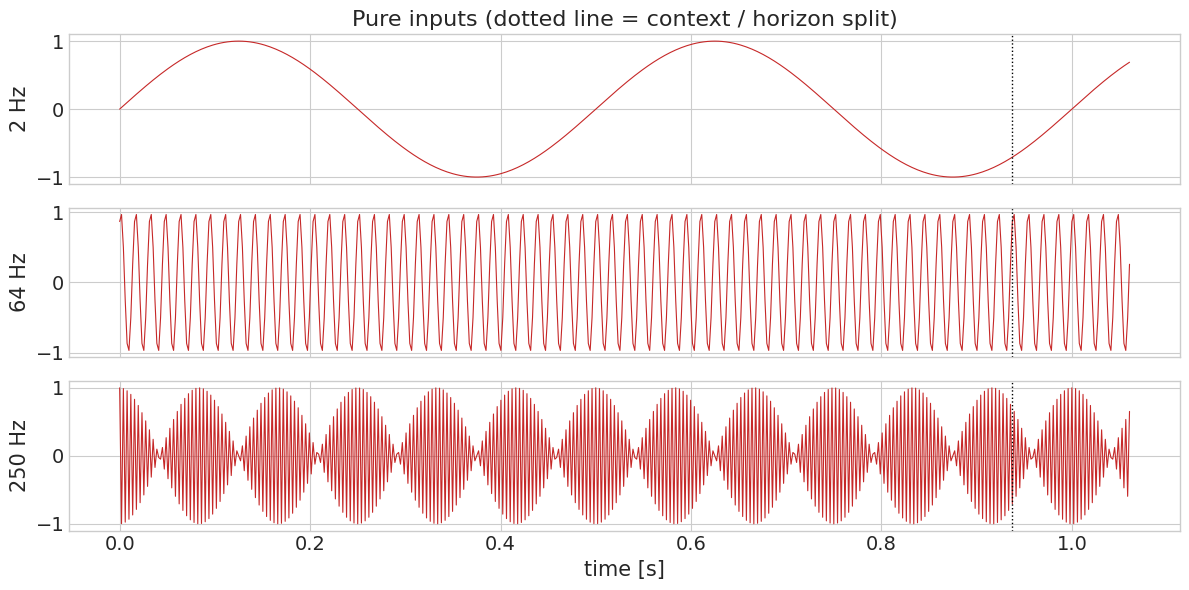


contrast observations by input mode:


model,p16-s16
generator,
pure,70


In [14]:
sig_dir = DATA_DIR / "signals"
index_path = sig_dir / "signals_index.parquet"
spec_path = sig_dir / "input_spec.json"
if index_path.exists() and spec_path.exists():
    sig_index = pd.read_parquet(index_path)
    print(json.loads(spec_path.read_text(encoding="utf-8")))
    display(sig_index)

    fig, axes = plt.subplots(len(sig_index), 1, figsize=(12, 6), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, row in zip(axes, sig_index.itertuples(index=False)):
        signal = np.load(sig_dir / row.file)
        time = np.arange(len(signal)) / pl.FS
        ax.plot(time, signal, lw=.8, color="#c62828")
        ax.axvline(pl.CTX / pl.FS, color="k", ls=":", lw=1)
        ax.set_ylabel(f"{row.frequency:g} Hz")
    axes[0].set_title("Pure inputs (dotted line = context / horizon split)")
    axes[-1].set_xlabel("time [s]")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "P2_signals.png", dpi=140, bbox_inches="tight")
    plt.show()
else:
    print(f"no pure signal archive at {sig_dir}; run Part 2 with Chronos available")

print("\ncontrast observations by input mode:")
display(contrasts.groupby(["generator", "model"]).size().unstack(fill_value=0))


## 2.1, Does the design support the inference?

Before any sampling, three questions have to be answered *yes*, because no prior can rescue a
design that cannot see the effect:

1. does every contrast have both of its controls (no missing triplet legs)?
2. are both `IsLocked` levels populated in every geometry, so $\theta_{lock}$ is identified?
3. are there rows where a tone is recovered at all? Where recovery is ~0 at the lock *and* at both
   controls, the contrast is a ratio of two noise floors and carries no information about H1, such
   rows are flagged `live = False` and excluded from Model A.

The third point is the honest limitation of this design: the retrained variants were given half the
published training budget, so above the reconstruction ceiling they forecast nothing anywhere, and
those frequencies simply cannot speak to H1.

In [15]:
bal = (contrasts.groupby(["model", "P", "S"])
       .agg(rows=("d", "size"), live=("live", "sum"),
            locks=("f_lock", "nunique"), phases=("phase_idx", "nunique"),
            generators=("generator", "nunique"), input_replicates=("bg_id", "nunique"),
            mean_R_lock=("R_lock", "mean"), mean_R_ctrl=("R_ctrl", "mean"))
       .reset_index())
bal["live_frac"] = (bal["live"] / bal["rows"]).round(3)
display(bal)

lock_bal = (mdl_cells.groupby(["model", "is_locked"]).size().unstack(fill_value=0)
            .rename(columns={0: "cells_unlocked", 1: "cells_locked"}))
display(lock_bal)

assert (lock_bal > 0).all().all(), "theta_lock is not identified: a geometry has an empty IsLocked level"
assert contrasts[["R_lock", "R_lo", "R_hi"]].notna().all().all(), "incomplete contrast triplets"
assert not contrasts.duplicated(["model", "f_lock", "phase"]).any(), "duplicate pure phases"
assert mdl_cells["n"].eq(2 * CFG.mdl_n_per_class).all(), "MDL cells are not equally sized"
print("design check passed: both IsLocked levels populated everywhere, all triplets complete.")

,model,P,S,rows,live,locks,phases,generators,input_replicates,mean_R_lock,mean_R_ctrl,live_frac
0,p16-s16,16,16,70,30,7,10,1,1,0.174774,0.047924,0.429


is_locked,cells_unlocked,cells_locked
model,,
p16-s16,140,70


design check passed: both IsLocked levels populated everywhere, all triplets complete.


## 2.2, What the raw data look like

Two descriptive views, so the modelling that follows is not done blind. Neither is inference, they
exist so that a posterior which disagrees with the picture gets questioned rather than believed.

C:\Users\bonio\AppData\Local\Temp\ipykernel_29268\1142350999.py:26: UserWarning: The figure layout has changed to tight
  fig.tight_layout(); fig.savefig(FIG_DIR / "P2_raw_data.png", dpi=140, bbox_inches="tight"); plt.show()


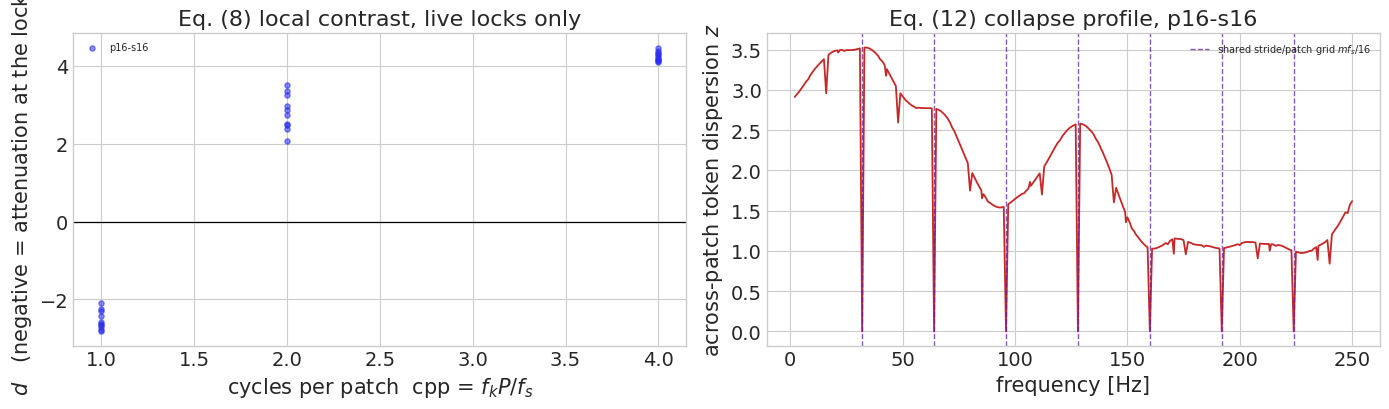

,model,P,S,mode,n_sites,f1,delta_hat,fs_over_S,fs_over_P
6,p16-s16,16,16,pure,0,NaN,NaN,32.0,32.0
7,p16-s16,16,16,pure,0,NaN,NaN,32.0,32.0


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

# (a) the contrast d against cycles-per-patch, live rows only. d<0 is the localized loss H1 predicts.
live = contrasts[contrasts["live"]].reset_index(drop=True)
for model, g in live.groupby("model"):
    axes[0].scatter(g["cpp"], g["d"], s=14, alpha=.55, label=model)
axes[0].axhline(0, color="k", lw=.9)
axes[0].set_xlabel("cycles per patch  cpp = $f_k P / f_s$")
axes[0].set_ylabel("$d$   (negative = attenuation at the lock)")
axes[0].set_title("Eq. (8) local contrast, live locks only"); axes[0].legend(fontsize=7)

# (b) the collapse profile, with the shared stride/patch grid drawn once
sub = collapse[(collapse["model"] == "p16-s16") & (collapse["mode"] == "pure")]
if len(sub) == 0:
    sub = collapse[collapse["model"] == collapse["model"].iloc[0]]
prof = sub.groupby("f", as_index=False)["z"].mean().sort_values("f")
P0, S0 = int(sub["P"].iloc[0]), int(sub["S"].iloc[0])
axes[1].plot(prof["f"], prof["z"], color="#c62828", lw=1.3)
assert P0 == S0
for j, f in enumerate(pl.stride_locks(S0)):
    axes[1].axvline(f, color="#6a1b9a", ls="--", lw=1, alpha=.75,
                    label=f"shared stride/patch grid $m f_s/16$" if j == 0 else None)
axes[1].set_xlabel("frequency [Hz]"); axes[1].set_ylabel("across-patch token dispersion $z$")
axes[1].set_title(f"Eq. (12) collapse profile, p{P0}-s{S0}"); axes[1].legend(fontsize=7)

fig.tight_layout(); fig.savefig(FIG_DIR / "P2_raw_data.png", dpi=140, bbox_inches="tight"); plt.show()

display(sites[sites.rep == -1][["model", "P", "S", "mode", "n_sites", "f1", "delta_hat"]]
        .assign(fs_over_S=lambda d: (pl.FS / d["S"]).round(2),
                fs_over_P=lambda d: (pl.FS / d["P"]).round(2)).round(2))

---
# Part 3, The likelihood

Part 1 fixed the priors; Part 2 produced the observations. This part supplies the third ingredient
and, more importantly, **checks that it works before it is trusted**.

Three things happen here:

1. **Section 3.1, the likelihood, written out.** The Student-$t_4$ density that Eq. (9) prescribes is
   implemented directly in NumPy and checked against SciPy. Seeing it as an explicit function makes
   concrete what the sampler is otherwise doing invisibly, and shows *why* $t_4$ rather than a
   Gaussian: its tails make a handful of extreme contrasts cost far less, so the population effect
   is not dragged around by them.
2. **Section 3.2, the model factories.** Each is a small factory function returning a PyMC model.
3. **Section 3.3, parameter recovery.** The likelihood is used to *simulate* contrasts with a known
   effect on the real design matrix, and the model is refitted. If a known $\log 0.5$ cannot be
   recovered from this design, no posterior fitted on the real data means anything.

## 3.1, The Student-$t_4$ contrast likelihood

For observation $i$ with linear predictor $\mu_i$ and scale $\sigma$,

$$\log p(d_i \mid \mu_i, \sigma, \nu) = \log\Gamma\!\Big(\tfrac{\nu+1}{2}\Big) - \log\Gamma\!\Big(\tfrac{\nu}{2}\Big) - \tfrac12\log(\pi\nu) - \log\sigma - \tfrac{\nu+1}{2}\log\!\Big(1 + \tfrac{(d_i-\mu_i)^2}{\nu\sigma^2}\Big).$$

The last term is the whole point. A Gaussian charges a residual quadratically, so one contrast ten
scale units away costs 50 units of log-likelihood and the fit will contort itself to reduce it. The
$t_4$ charges it logarithmically, about 5 units, so an outlier is *tolerated* rather than
obeyed. With recovery ratios that can collapse to ~0 at a dead frequency, that robustness is not a
stylistic preference; it is what keeps a handful of dead cells from setting $\bar\beta$.

PART 3, LIKELIHOOD
student_t_logpdf matches scipy.stats.t.logpdf to machine precision


C:\Users\bonio\AppData\Local\Temp\ipykernel_29268\1840296732.py:24: UserWarning: The figure layout has changed to tight
  fig.tight_layout(); fig.savefig(FIG_DIR / "P3_likelihood.png", dpi=140, bbox_inches="tight"); plt.show()


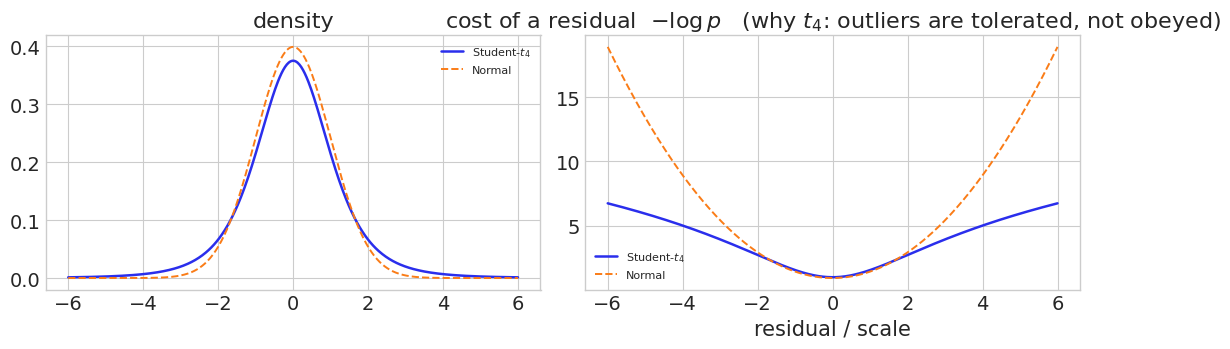

In [17]:
banner("PART 3, LIKELIHOOD")

from scipy.special import gammaln

def student_t_logpdf(d, mu, sigma, nu=NU):
    """Log density of Student-t(nu, mu, sigma), written out rather than imported."""
    z2 = ((np.asarray(d) - mu) / sigma) ** 2
    return (gammaln((nu + 1) / 2) - gammaln(nu / 2) - 0.5 * np.log(np.pi * nu)
            - np.log(sigma) - (nu + 1) / 2 * np.log1p(z2 / nu))

# cross-check against SciPy: the two must agree to machine precision
_d = np.linspace(-6, 6, 501)
assert np.allclose(student_t_logpdf(_d, 0.3, 0.7), stats.t.logpdf(_d, NU, loc=0.3, scale=0.7))
print("student_t_logpdf matches scipy.stats.t.logpdf to machine precision")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(_d, np.exp(student_t_logpdf(_d, 0, 1)), label=r"Student-$t_4$", lw=1.8)
ax[0].plot(_d, stats.norm.pdf(_d), label="Normal", lw=1.4, ls="--")
ax[0].set_title("density"); ax[0].legend(fontsize=8)
ax[1].plot(_d, -student_t_logpdf(_d, 0, 1), label=r"Student-$t_4$", lw=1.8)
ax[1].plot(_d, -stats.norm.logpdf(_d), label="Normal", lw=1.4, ls="--")
ax[1].set_title("cost of a residual  $-\\log p$   (why $t_4$: outliers are tolerated, not obeyed)")
ax[1].legend(fontsize=8); ax[1].set_xlabel("residual / scale")
fig.tight_layout(); fig.savefig(FIG_DIR / "P3_likelihood.png", dpi=140, bbox_inches="tight"); plt.show()

### A rough likelihood-location diagnostic

An intercept-only profile is useful as a quick sanity check that the observed contrasts contain a
location signal on the scale covered by the prior. It is not a substitute for the hierarchical
fit or the parameter-recovery experiment below, so it is treated as a diagnostic rather than proof
that the complete design is identifiable.

C:\Users\bonio\AppData\Local\Temp\ipykernel_29268\3413585775.py:13: UserWarning: The figure layout has changed to tight
  fig.tight_layout(); fig.savefig(FIG_DIR / "P3_profile.png", dpi=140, bbox_inches="tight"); plt.show()


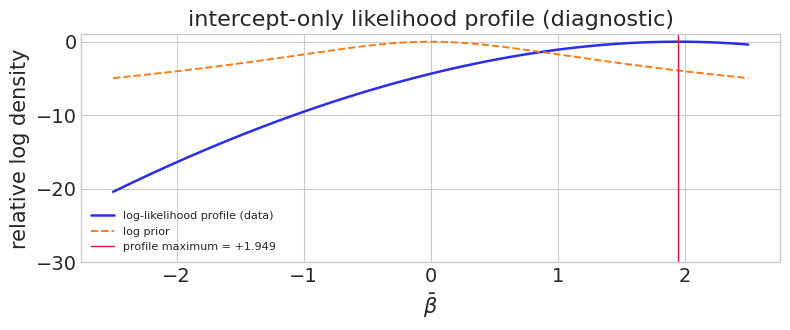

In [18]:
d_live = live["d"].to_numpy()
grid_b = np.linspace(-2.5, 2.5, 400)
ll = np.array([student_t_logpdf(d_live, b, np.std(d_live)).sum() for b in grid_b])
prior_ll = stats.t.logpdf(grid_b, NU, scale=PRIOR_SCALE)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(grid_b, ll - ll.max(), label="log-likelihood profile (data)", lw=1.8)
ax.plot(grid_b, prior_ll - prior_ll.max(), label="log prior", lw=1.4, ls="--")
ax.axvline(grid_b[ll.argmax()], color="crimson", lw=1,
           label=f"profile maximum = {grid_b[ll.argmax()]:+.3f}")
ax.set_xlabel(r"$\bar\beta$"); ax.set_ylabel("relative log density"); ax.set_ylim(-30, 1)
ax.legend(fontsize=8); ax.set_title("intercept-only likelihood profile (diagnostic)")
fig.tight_layout(); fig.savefig(FIG_DIR / "P3_profile.png", dpi=140, bbox_inches="tight"); plt.show()

## 3.2, PyMC model factories and identifiability guards

Each factory takes a dataframe and returns a model. Two implementation notes that matter for the
sampler rather than for the statistics:

* **Non-centred parameterisation.** Group effects are written $u = \sigma_u z$ with
  $z\sim\mathcal N(0,1)$ rather than $u\sim\mathcal N(0,\sigma_u)$. The two are the same
  distribution, but the first gives NUTS a geometry without the funnel that produces divergences
  when a group scale is small, which it will be here if H2 holds.
* **`log_likelihood=True`.** Pointwise log-likelihoods are stored so that Part 4 and Part 5 can run
  leave-one-out comparisons, which is how the deliverable compares competing hypotheses instead of
  running null-hypothesis tests.

In [19]:
def _codes(series):
    """Integer codes plus the ordered level names, for PyMC `coords`."""
    codes, levels = pd.factorize(series)
    return np.asarray(codes), list(map(str, levels))


def _overlap_scaled(df: pd.DataFrame, cfg_levels: list[str]) -> np.ndarray:
    """Centred, scaled patch overlap O = (P-S)/P; one unit = 0.5 of overlap."""
    O = df.groupby("model")["overlap"].first().reindex(cfg_levels).to_numpy(float)
    return (O - O.mean()) / 0.5


def _logP_centred(df: pd.DataFrame, cfg_levels: list[str]) -> np.ndarray:
    """Centred log patch size.

    deliverable2.tex, H1: "The overlap enters as a ratio and the patch size as log P, because the
    patch grid has spacing fs/P: equal steps in log P are then equal ratios of spacing." On a raw-P
    scale one coefficient would make 8->16 and 16->24 the same change, which the geometry does not.
    """
    Pv = df.groupby("model")["P"].first().reindex(cfg_levels).to_numpy(float)
    lp = np.log(Pv)
    return lp - lp.mean()


# --------------------------------------------------------------------------------------- #
def model_A_contrast(df: pd.DataFrame, scale: float = PRIOR_SCALE, nu: int = NU,
                     likelihood: str = "student", config_level: str = "none") -> pm.Model:
    """Model A, H1 behavioural; configuration slopes require multiple checkpoints.

        d_i ~ Student-t(nu, mu_i, sigma)
        mu_i = beta[config_i] + u_harm[i]
        beta_c ~ Normal(beta_bar + delta_O * Otilde_c + delta_P * logPtilde_c, tau)

    `config_level` is retained for compatibility with a genuine multi-geometry design. This
    p16-s16 notebook uses `none`: overlap and patch-size slopes cannot be learned from one point.

        "both"     beta_bar + delta_O * Otilde + delta_P * logPtilde   (the reported model)
        "overlap"  beta_bar + delta_O * Otilde
        "patch"    beta_bar + delta_P * logPtilde
        "none"     beta_bar

    `likelihood="normal"` swaps in a Gaussian for the Part 5 robustness check.
    """
    cfg_c, cfg_l = _codes(df["model"])
    harm_c, harm_l = _codes(df["f_lock"].round(3).astype(str))
    O_t = _overlap_scaled(df, cfg_l)
    lP_t = _logP_centred(df, cfg_l)
    y = df["d"].to_numpy(float)
    if len(cfg_l) < 2 and config_level != "none":
        raise ValueError("configuration slopes need at least two geometries")

    coords = {"config": cfg_l, "harmonic": harm_l, "obs": np.arange(len(y))}
    with pm.Model(coords=coords) as m:
        #, population level: the estimand of H1 -------------------------------------
        beta_bar = pm.StudentT("beta_bar", nu=nu, mu=0.0, sigma=scale)
        cfg_mean = beta_bar
        if config_level in ("both", "overlap"):
            delta_O = pm.StudentT("delta_O", nu=nu, mu=0.0, sigma=scale)   # M1
            cfg_mean = cfg_mean + delta_O * O_t
        if config_level in ("both", "patch"):
            delta_P = pm.StudentT("delta_P", nu=nu, mu=0.0, sigma=scale)
            cfg_mean = cfg_mean + delta_P * lP_t

        # A single checkpoint has no between-configuration variance to estimate.
        if len(cfg_l) == 1:
            beta = pm.Deterministic("beta", pm.math.stack([beta_bar]), dims="config")
        else:
            tau = pm.HalfStudentT("tau", nu=nu, sigma=scale)
            z_cfg = pm.Normal("z_cfg", 0.0, 1.0, dims="config")
            beta = pm.Deterministic("beta", cfg_mean + tau * z_cfg, dims="config")

        sigma_h = pm.HalfStudentT("sigma_harm", nu=nu, sigma=scale)
        u_h = pm.Deterministic("u_harm", sigma_h * pm.Normal("z_harm", 0.0, 1.0, dims="harmonic"),
                               dims="harmonic")
        mu = beta[cfg_c] + u_h[harm_c]
        sigma = pm.HalfStudentT("sigma", nu=nu, sigma=scale)
        if likelihood == "normal":
            pm.Normal("d", mu=mu, sigma=sigma, observed=y, dims="obs")
        else:
            pm.StudentT("d", nu=nu, mu=mu, sigma=sigma, observed=y, dims="obs")

        # reported on the natural scale: the multiplicative change in recovery at a lock
        pm.Deterministic("recovery_ratio", pm.math.exp(beta_bar))
    return m


# --------------------------------------------------------------------------------------- #
def model_B_codelength(df: pd.DataFrame, adjusted: bool = True) -> pm.Model:
    """Model B, H1 representational.  Deliverable Eq. (10).

        y_i ~ Gamma(shape=k, mean=mu_i),   log mu_i = alpha_0 + theta_lock * IsLocked

    `adjusted=True` adds zero-mean stage offsets and, only when identifiable, geometry offsets.
    Eq. (10) taken literally pools
    codelengths from probe stages whose scales differ several-fold, which inflates the residual
    without touching the estimand; blocking on stage is the standard remedy and leaves theta_lock
    exactly as specified. The two versions are compared by LOO in Part 4.
    """
    y = np.clip(df["L_bits"].to_numpy(float), 1e-3, None)    # Gamma support is strictly positive
    locked = df["is_locked"].to_numpy(float)
    st_c, st_l = _codes(df["stage"])
    mo_c, mo_l = _codes(df["model"])

    coords = {"stage": st_l, "geometry": mo_l, "obs": np.arange(len(y))}
    with pm.Model(coords=coords) as m:
        alpha0 = pm.Normal("alpha_0", mu=float(np.log(40.0)), sigma=1.0)
        theta = pm.Normal("theta_lock", mu=0.0, sigma=0.5)       # the estimand
        k = pm.Gamma("k", alpha=2.0, beta=0.1)                   # Gamma shape (dispersion)

        log_mu = alpha0 + theta * locked
        if adjusted:
            s_st = pm.HalfNormal("sigma_stage", 1.0)
            eff_st = pm.Deterministic("eff_stage", s_st * pm.Normal("z_stage", 0, 1, dims="stage"),
                                      dims="stage")
            log_mu = log_mu + eff_st[st_c]
            if len(mo_l) > 1:
                s_mo = pm.HalfNormal("sigma_geometry", 1.0)
                eff_mo = pm.Deterministic("eff_geometry",
                                          s_mo * pm.Normal("z_geometry", 0, 1, dims="geometry"),
                                          dims="geometry")
                log_mu = log_mu + eff_mo[mo_c]

        mu = pm.math.exp(log_mu)
        pm.Gamma("y", alpha=k, beta=k / mu, observed=y, dims="obs")
        pm.Deterministic("codelength_ratio", pm.math.exp(theta))
    return m


# --------------------------------------------------------------------------------------- #
N_PHASE_BINS = 8       # how many equal slices of the phase circle get their own offset

def model_C_phase(df: pd.DataFrame, with_phase: bool = True, scale: float = PRIOR_SCALE,
                  nu: int = NU) -> pm.Model:
    """Model C, H2.  Does the lock deficit depend on WHERE in its cycle the signal starts?

        y_i = log(R_ctrl + .01) - log(R_lock + .01)          (the deficit; = -d)
        E[y_i] = beta[config] + u_harm + u_phase[bin of phi_i]
        u_phase ~ Normal(0, sigma_phase)

    The phase circle is cut into N_PHASE_BINS equal slices and each slice gets its own offset.
    `sigma_phase` is then the spread of those offsets: how much the deficit moves as the signal
    slides through its cycle. H2 says the deficit is a property of the stride/patch geometry, not
    of the signal's phase, i.e. sigma_phase ~ 0.

    This replaced a first-harmonic (a cos phi + b sin phi) formulation. The variance component is
    easier to state and to defend, it is the direct Bayesian counterpart of the phase spread the
    project's frequentist suite already reports, and it is strictly more general: it catches ANY
    dependence on phase, not only a sinusoidal one.

    `with_phase=False` builds the nested null with no phase term, for the LOO comparison.
    """
    cfg_c, cfg_l = _codes(df["model"])
    harm_c, harm_l = _codes(df["f_lock"].round(3).astype(str))
    # Pure sinusoids have no background grouping factor; phase is the only input-level axis.
    # phase matters only modulo 2*pi: it is the tone's alignment with the patch grid
    phi = np.mod(df["phase"].to_numpy(float), 2 * np.pi)
    bin_c = np.floor(phi / (2 * np.pi / N_PHASE_BINS)).astype(int)
    bin_l = [f"{j * 360 // N_PHASE_BINS}-{(j + 1) * 360 // N_PHASE_BINS} deg" for j in range(N_PHASE_BINS)]
    y = df["y_deficit"].to_numpy(float)

    coords = {"config": cfg_l, "harmonic": harm_l, "phasebin": bin_l,
              "obs": np.arange(len(y))}
    with pm.Model(coords=coords) as m:
        beta_bar = pm.StudentT("beta_bar", nu=nu, mu=0.0, sigma=scale)
        if len(cfg_l) == 1:
            beta = pm.Deterministic("beta", pm.math.stack([beta_bar]), dims="config")
        else:
            tau = pm.HalfStudentT("tau", nu=nu, sigma=scale)
            beta = pm.Deterministic("beta",
                                    beta_bar + tau * pm.Normal("z_cfg", 0, 1, dims="config"),
                                    dims="config")
        sigma_h = pm.HalfStudentT("sigma_harm", nu=nu, sigma=scale)
        u_h = pm.Deterministic("u_harm", sigma_h * pm.Normal("z_harm", 0, 1, dims="harmonic"),
                               dims="harmonic")
        mu = beta[cfg_c] + u_h[harm_c]
        if with_phase:
            # the estimand: the spread of the per-phase offsets
            sigma_phase = pm.HalfNormal("sigma_phase", 0.25)
            u_p = pm.Deterministic("u_phase",
                                   sigma_phase * pm.Normal("z_phase", 0, 1, dims="phasebin"),
                                   dims="phasebin")
            mu = mu + u_p[bin_c]

        sigma = pm.HalfStudentT("sigma", nu=nu, sigma=scale)
        pm.StudentT("y", nu=nu, mu=mu, sigma=sigma, observed=y, dims="obs")
    return m


# --------------------------------------------------------------------------------------- #
COMB_FLOOR = 1e-2      # z_norm floor before the log; see the note in Section 4.4
GRID_TOL_HZ = 1e-6     # pure-sinusoid collapse is pointwise: label exact grid sites only

def model_D1_sites(df: pd.DataFrame, grid: str, comb_floor: float = COMB_FLOOR) -> pm.Model:
    """Model D1, H3 location.  Deliverable Eq. (12).

        log z_g(f) ~ Normal(alpha_g + one mutually-exclusive grid effect, sigma)

    Each frequency is labelled by which predicted grid it falls on (within GRID_TOL_HZ), and the
    model asks whether token dispersion is systematically lower there. For p16-s16, H3 predicts
    the identified shared-grid coefficient theta_B < 0.

    `grid` selects the labelling: "shared" is the only identified grid effect when P=S;
    "both" is retained for multi-geometry use, while "stride" and "patch" use one whole grid.
    The four are fitted on identical observations and
    compared by LOO. The target P=S geometry cannot separate the two families, so only `shared`
    versus `none` is fitted in Part 4.

    This is deliberately the same shape of model as Eq. (10): a linear predictor on a log scale
    with an indicator variable. It replaced an earlier Gaussian-dip "comb" likelihood with free
    depth and width, which estimated two nuisance quantities nothing downstream used and was far
    harder to justify than the claim it was testing.
    """
    g_c, g_l = _codes(df["model"])
    if not (0 < comb_floor < 1):
        raise ValueError("comb_floor must lie in (0, 1)")
    logz = np.log(np.clip(df["z_norm"].to_numpy(float), comb_floor, None))

    # membership indicators, built from the same helper that defines the grids everywhere else
    on_stride = np.zeros(len(df))
    on_patch = np.zeros(len(df))
    for gi, _name in enumerate(g_l):
        sel = g_c == gi
        P = int(df.loc[sel, "P"].iloc[0]); S = int(df.loc[sel, "S"].iloc[0])
        f = df.loc[sel, "f"].to_numpy(float)
        on_stride[sel] = (pl.comb_distance(f, pl.FS / S) <= GRID_TOL_HZ).astype(float)
        on_patch[sel] = (pl.comb_distance(f, pl.FS / P) <= GRID_TOL_HZ).astype(float)

    on_both = on_stride * on_patch
    on_stride_only = on_stride * (1.0 - on_patch)
    on_patch_only = on_patch * (1.0 - on_stride)

    coords = {"geometry": g_l, "obs": np.arange(len(logz))}
    with pm.Model(coords=coords) as m:
        alpha_g = pm.Normal("alpha_g", 0.0, 1.0, dims="geometry")
        sigma = pm.HalfNormal("sigma", 1.0)
        mu = alpha_g[g_c]
        if grid == "shared":
            if not np.array_equal(on_stride, on_patch):
                raise ValueError("shared-grid D1 requires coincident stride and patch grids")
            theta_B = pm.Normal("theta_B", 0.0, 1.0)
            mu = mu + theta_B * on_both
        elif grid == "both":
            theta_S = pm.Normal("theta_S", 0.0, 1.0)
            theta_P = pm.Normal("theta_P", 0.0, 1.0)
            theta_B = pm.Normal("theta_B", 0.0, 1.0)
            mu = (mu + theta_S * on_stride_only + theta_P * on_patch_only
                  + theta_B * on_both)
        elif grid == "stride":
            theta_S = pm.Normal("theta_S", 0.0, 1.0)
            mu = mu + theta_S * on_stride
        elif grid == "patch":
            theta_P = pm.Normal("theta_P", 0.0, 1.0)
            mu = mu + theta_P * on_patch
        elif grid != "none":
            raise ValueError(f"unknown D1 grid specification {grid!r}")
        pm.Normal("logz", mu=mu, sigma=sigma, observed=logz, dims="obs")
    return m


# --------------------------------------------------------------------------------------- #
def model_D2_movement(df: pd.DataFrame, branch: str, resolution_hz: float | None = None,
                      response: str = "f1") -> pm.Model:
    """Models D2, H3a and H3b.  One scaling law per branch, no intercept.

        f1_hat[g] ~ Normal(kappa_F * Delta_F[g], sqrt(sigma_F^2 + df^2))

    deliverable2.tex, H3: every detected dip is first assigned to the branch that predicts it and
    ambiguous sites are set aside, then the fundamental of that branch is compared with the spacing
    that branch predicts, Delta_S = fs/S or Delta_P = fs/P. H3a predicts kappa_S = 1 and H3b
    predicts kappa_P = 1: each branch tracks its own parameter one for one.

    This replaced a single regression of one pooled spacing on BOTH predictors, with an intercept
    and the prediction kappa_P = 0. That formulation contradicted H3 as approved in Deliverable 1,
    which claims that each branch moves with its own parameter; and it treated the detected set as
    one comb, when F_lock is generally a union of two interlaced combs.

    **Measurement resolution.** The spacing is read off a frequency sweep, so it carries a floor of
    about one grid step whatever the sampling noise. Stating it is not cosmetic: when the sites land
    on the predicted comb exactly, the residuals vanish, sigma is pushed to zero and the posterior
    develops a funnel NUTS cannot traverse (R-hat above 2, hundreds of divergences). Adding the
    floor in quadrature removes the pathology and is the honest statement: a near-zero sigma is then
    a result, the spacings follow the law to within the sweep resolution, not a sampler failure.

    `response="f1"` uses the branch's fundamental, the lowest detected site of that branch, which is
    what the deliverable specifies. `response="delta_hat"` uses the median gap of the same branch and
    is fitted only as a robustness check: with three or four sites in band one spurious detection
    inserts a short interval and flips the median, to which the fundamental is immune.
    """
    sub = df[df["branch"] == branch]
    y = sub[response].to_numpy(float)                      # measured spacing [Hz]
    x = sub["predicted_spacing"].to_numpy(float)           # fs/S or fs/P [Hz]
    name = {"stride": "kappa_S", "patch": "kappa_P"}[branch]
    if len(y) == 0 or not np.isfinite(y).all():
        raise ValueError(f"D2 {branch} branch has no finite observations")
    if np.unique(np.round(x, 9)).size < 2:
        raise ValueError(f"D2 {branch} movement needs at least two predicted spacings")

    step = resolution_hz if resolution_hz is not None else CFG.collapse_step
    with pm.Model(coords={"obs": np.arange(len(y))}) as m:
        kappa = pm.Normal(name, mu=0.0, sigma=1.0)         # H3a / H3b predict 1
        sigma_d = pm.HalfNormal("sigma_extra", 5.0)        # scatter beyond the grid floor [Hz]
        sigma_total = pm.math.sqrt(sigma_d ** 2 + step ** 2)
        pm.Normal("f1_hat", mu=kappa * x, sigma=sigma_total, observed=y, dims="obs")
    return m


def sample(model, name: str, draws=None, tune=None, chains=None, **kw):
    """One place for the sampler settings the deliverable's Inference paragraph prescribes.

    `NUTS_BACKEND` (set in Part 0.3) selects who does the sampling. The model, the priors and the
    number of draws are identical in every case; only the implementation of NUTS changes, so the
    posterior is the same target distribution.

      "pymc"     the default. Pure Python/PyTensor, CPU only.
      "nutpie"   a Rust implementation, several times faster on the same CPU.
      "numpyro"  JAX. This is the one that uses a GPU, and the only reason a GPU runtime helps:
                 PyMC's own sampler never touches it. Chains run vectorised rather than in series.
    """
    extra = dict(kw)
    if NUTS_BACKEND != "pymc":
        extra["nuts_sampler"] = NUTS_BACKEND
        if NUTS_BACKEND == "numpyro":
            extra.setdefault("nuts_sampler_kwargs", {"chain_method": "vectorized"})
    with model:
        return pm.sample(draws=draws or DRAWS, tune=tune or TUNE, chains=chains or CHAINS,
                         cores=1, random_seed=SEED, target_accept=TARGET_ACCEPT,
                         progressbar=False, idata_kwargs={"log_likelihood": True}, **extra)

print("model factories ready: A (H1 behavioural), B (H1 representational), "
      "C (H2), D1 shared-grid (H3); D2 is guarded and not identified for p16-s16")

model factories ready: A (H1 behavioural), B (H1 representational), C (H2), D1 shared-grid (H3); D2 is guarded and not identified for p16-s16


## 3.3, Parameter recovery: can this design see an effect that is really there?

A posterior centred on zero has two possible readings: there is no effect, or the design cannot see
one. The two are distinguished *before* looking at the real posterior, by simulating contrasts on
the **real design matrix** with a known $\bar\beta$ and refitting.

Four truths are used, spanning the range the deliverable cares about: no effect, 20% attenuation
(the reporting threshold), 50%, and 90%. Recovery is judged by whether the 95% credible interval
covers the truth and by how much the posterior has narrowed relative to the prior.

In [20]:
def simulate_from_A(df: pd.DataFrame, beta_true: float, seed: int = SEED) -> pd.DataFrame:
    """Replace the observed d with data simulated from Model A at a known population effect."""
    rng = np.random.default_rng(seed)
    out = df.copy()
    harm_c, harm_l = _codes(out["f_lock"].round(3).astype(str))
    # modest harmonic structure, matching the identified hierarchy in the p16-s16 model
    u_h = rng.normal(0, 0.20, len(harm_l))
    mu = beta_true + u_h[harm_c]
    out["d"] = mu + 0.30 * stats.t.rvs(NU, size=len(out), random_state=rng.integers(1 << 31))
    return out


TRUTHS = {"no effect": 0.0, "20% attenuation": np.log(0.8),
          "50% attenuation": np.log(0.5), "90% attenuation": np.log(0.1)}

if have("03_recovery.parquet"):
    recovery_tbl = load_df("03_recovery.parquet")
else:
    rec_rows = []
    for label, truth in TRUTHS.items():
        sim_df = simulate_from_A(live, truth)
        idata = sample(model_A_contrast(sim_df), f"recovery_{label}",
                       draws=max(400, DRAWS // 2), tune=max(400, TUNE // 2), chains=2)
        post = idata.posterior["beta_bar"].values.ravel()
        lo, hi = np.quantile(post, [0.025, 0.975])
        rec_rows.append(dict(scenario=label, true_beta=truth, posterior_median=float(np.median(post)),
                             hdi_lo=float(lo), hdi_hi=float(hi), covers_truth=bool(lo <= truth <= hi),
                             posterior_sd=float(post.std()), prior_sd=float(PRIOR_SCALE * np.sqrt(NU / (NU - 2))),
                             divergences=int(idata.sample_stats["diverging"].values.sum())))
    recovery_tbl = save_df(pd.DataFrame(rec_rows), "03_recovery.parquet")

recovery_tbl["shrinkage"] = (1 - recovery_tbl["posterior_sd"] / recovery_tbl["prior_sd"]).round(3)
display(recovery_tbl.round(4))

if recovery_tbl["covers_truth"].all():
    print("\nPARAMETER RECOVERY PASSED for the checked scenarios: the intervals cover the injected "
          "effects and narrow relative to the prior. This supports, but does not by itself prove, "
          "that the complete analysis can distinguish a small effect from weak identification.")
else:
    bad = recovery_tbl[~recovery_tbl["covers_truth"]]["scenario"].tolist()
    print(f"\nPARAMETER RECOVERY FAILED for {bad}, do not interpret Part 4 until this is resolved.")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [beta_bar, sigma_harm, z_harm, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 340 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [beta_bar, sigma_harm, z_harm, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 423 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [beta_bar, sigma_harm, z_harm, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 357 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+

  checkpoint -> 03_recovery.parquet


,scenario,true_beta,posterior_median,hdi_lo,hdi_hi,covers_truth,posterior_sd,prior_sd,divergences,shrinkage
0,no effect,0.0000,0.0419,-0.3872,0.5293,True,0.2246,0.7071,0,0.682
1,20% attenuation,-0.2231,-0.1402,-0.6070,0.3657,True,0.2346,0.7071,0,0.668
2,50% attenuation,-0.6931,-0.5339,-1.0516,0.0605,True,0.2654,0.7071,0,0.625
3,90% attenuation,-2.3026,-2.1362,-2.6188,-1.2945,True,0.3183,0.7071,0,0.550



PARAMETER RECOVERY PASSED for the checked scenarios: the intervals cover the injected effects and narrow relative to the prior. This supports, but does not by itself prove, that the complete analysis can distinguish a small effect from weak identification.


---
# Part 4, Posterior inference

Priors are fixed, the data are in, the likelihood is validated. This part fits the five models and
reports, for each, what the deliverable's *Inference* paragraph asks for: the effect on its natural
scale with a 95% credible interval, the posterior probability of the preregistered threshold, and,
where two formulations compete, a leave-one-out comparison rather than a null-hypothesis test.

Every fit is checkpointed individually, so a disconnect costs at most one model.

In [21]:
banner("PART 4, POSTERIOR INFERENCE")

def report(idata, var: str, transform=None, label: str = "") -> dict:
    """Posterior median + 95% credible interval for one parameter, on its natural scale."""
    x = idata.posterior[var].values.ravel()
    if transform is not None:
        x = transform(x)
    lo, hi = np.quantile(x, [0.025, 0.975])
    print(f"  {label or var:<24s} median {np.median(x):+.4f}   95% CrI [{lo:+.4f}, {hi:+.4f}]")
    return dict(parameter=label or var, median=float(np.median(x)),
                lo=float(lo), hi=float(hi), sd=float(x.std()))

def prob(idata, var: str, condition) -> float:
    return float(np.mean(condition(idata.posterior[var].values.ravel())))

PART 4, POSTERIOR INFERENCE


## 4.1, Model A: H1 at the behavioural level

**Estimand.** $\bar\beta$, the population log-ratio of forecast amplitude recovery at a phase-lock
against its matched controls. $e^{\bar\beta} < 1$ means the lock recovers *less*, which is what H1
predicts.

**Reported.** $e^{\bar\beta}$ with a 95% credible interval; $\Pr(\bar\beta<\log 0.8\mid D)$, the
probability of at least 20% attenuation; and $\Pr(|\bar\beta|<\log 1.1\mid D)$, the probability the
effect is practically nil. The p16-s16 effect is shown as a forest plot. No overlap or patch-size
slope is fitted because those quantities do not vary in this single-checkpoint design.

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [beta_bar, sigma_harm, z_harm, sigma]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4085 seconds.


  checkpoint -> 04_A.nc

Model A, H1 behavioural
  beta_bar (log ratio)     median +0.2351   95% CrI [-0.7554, +1.5926]
  recovery ratio exp(beta_bar) median +1.2650   95% CrI [+0.4698, +4.9163]

  P(at least 20% attenuation | D) = 0.173   (prior: 0.336)
  P(practically no effect  | D)   = 0.141   (ROPE |beta| < log 1.1)
  P(beta_bar < 0 | D)             = 0.316   (any attenuation at all)


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_bar,0.276,0.579,-0.851,1.468,0.011,0.013,2950.0,2387.0,1.0
sigma,0.255,0.046,0.172,0.347,0.001,0.001,4131.0,3950.0,1.0
sigma_harm,2.528,0.792,1.312,4.154,0.018,0.017,1985.0,2740.0,1.0


M1 NOT IDENTIFIED: p16-s16 supplies one overlap and one patch size only.


C:\Users\bonio\AppData\Local\Temp\ipykernel_29268\197387888.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.savefig(FIG_DIR / "P4_A_forest.png", dpi=140, bbox_inches="tight"); plt.show()


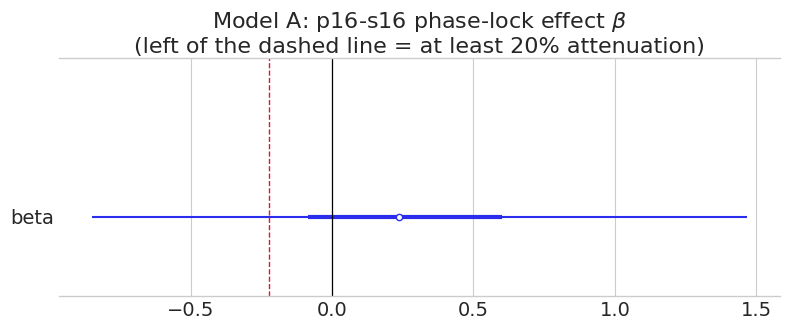

In [22]:
idata_A = cached_fit("04_A.nc", lambda: sample(model_A_contrast(live), "A"))

print("\nModel A, H1 behavioural")
rowsA = [report(idata_A, "beta_bar", label="beta_bar (log ratio)"),
         report(idata_A, "beta_bar", np.exp, label="recovery ratio exp(beta_bar)")]
pA_att = prob(idata_A, "beta_bar", lambda x: x < ATTENUATION_20)
pA_rope = prob(idata_A, "beta_bar", lambda x: np.abs(x) < ROPE_LOG)
pA_neg = prob(idata_A, "beta_bar", lambda x: x < 0)
print(f"\n  P(at least 20% attenuation | D) = {pA_att:.3f}   (prior: "
      f"{prior_summary['p_attenuation20_prior']:.3f})")
print(f"  P(practically no effect  | D)   = {pA_rope:.3f}   (ROPE |beta| < log 1.1)")
print(f"  P(beta_bar < 0 | D)             = {pA_neg:.3f}   (any attenuation at all)")

display(az.summary(idata_A, var_names=["beta_bar", "sigma", "sigma_harm"],
                   hdi_prob=0.95).round(3))

# M1 is structurally unavailable with one geometry; do not sample prior-only slopes.
print("M1 NOT IDENTIFIED: p16-s16 supplies one overlap and one patch size only.")

axes = az.plot_forest(idata_A, var_names=["beta"], combined=True, hdi_prob=0.95, figsize=(8, 3.4))
axes[0].axvline(0, color="k", lw=.9)
axes[0].axvline(ATTENUATION_20, color="crimson", ls="--", lw=1)
axes[0].set_title("Model A: p16-s16 phase-lock effect $\\beta$\n"
                  "(left of the dashed line = at least 20% attenuation)")
plt.tight_layout(); plt.savefig(FIG_DIR / "P4_A_forest.png", dpi=140, bbox_inches="tight"); plt.show()

## 4.2, Model B: H1 at the representational level

**Estimand.** $\theta_{lock}$, the log-ratio by which the frequency-local prequential codelength
expands at a locked frequency. $e^{\theta_{lock}} > 1$ means the representation needs *more* bits
to separate a locked frequency from its neighbours, information loss in the sense of Voita &
Titov, independent of whether the forecast happens to recover the tone.

This is the second half of the deliverable's original two-part framework, and it can disagree with
Model A. Model A asks whether the forecast rebuilds the tone; Model B asks whether the frequency is
still *readable* inside the network. A lock that is rebuilt but no longer distinguishable from its
neighbours would show up here and nowhere else.

The unadjusted form (Eq. (10) taken literally) is fitted alongside and compared by LOO, so the
blocking decision of Section 3.2 is reported rather than assumed.

In [ ]:
idata_B = cached_fit("04_B.nc", lambda: sample(model_B_codelength(mdl_cells, adjusted=True), "B"))
idata_B0 = cached_fit("04_B_unadjusted.nc",
                      lambda: sample(model_B_codelength(mdl_cells, adjusted=False), "B0"))

print("\nModel B, H1 representational")
rowsB = [report(idata_B, "theta_lock", label="theta_lock (log ratio)"),
         report(idata_B, "theta_lock", np.exp, label="codelength ratio exp(theta_lock)"),
         report(idata_B, "k", label="Gamma shape k")]
pB_exp = prob(idata_B, "theta_lock", lambda x: x > 0)
pB_20 = prob(idata_B, "theta_lock", lambda x: x > np.log(1.2))
pB_rope = prob(idata_B, "theta_lock", lambda x: np.abs(x) < ROPE_LOG)
print(f"\n  P(codelength expands at a lock | D) = {pB_exp:.3f}")
print(f"  P(expansion of at least 20%   | D)   = {pB_20:.3f}")
print(f"  P(practically no effect       | D)   = {pB_rope:.3f}")

display(az.summary(idata_B, var_names=["alpha_0", "theta_lock", "k"], hdi_prob=0.95).round(3))

cmpB = az.compare({"stage adjusted": idata_B, "Eq. (10) literal": idata_B0})
display(cmpB)
print("\nIf the adjusted model wins decisively, pooling probe stages of very different scale was "
      "indeed inflating the residual; theta_lock is unchanged in meaning either way.")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha_0, theta_lock, k, sigma_stage, z_stage]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 15401 seconds.


  checkpoint -> 04_B.nc


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha_0, theta_lock, k]


## 4.3, Model C: H2, is the deficit set by the geometry or by the phase?

**Estimand.** $\sigma_\phi$, the spread of the per-phase offsets. The phase circle is cut into
eight equal slices, each slice gets its own offset, and $\sigma_\phi$ says how far apart those
offsets are, that is, how much the lock deficit moves as the signal slides through its cycle.

H2 says the deficit is set by the stride/patch alignment and not by where the signal happens to
start, so it predicts $\sigma_\phi \approx 0$. Two readings are reported, answering different
questions:

* $\Pr(\sigma_\phi<\log 1.1\mid D)$, is the phase dependence *practically* negligible? (a
  magnitude question)
* LOO against the model with no phase term at all, does allowing phase to matter *predict better*?
  (an evidential question)

They can disagree, and the disagreement is informative: a small but consistently detected phase
dependence would show a low equivalence probability together with a LOO preference for the phase
model.

In [ ]:
idata_C = cached_fit("04_C.nc", lambda: sample(model_C_phase(live, with_phase=True), "C"))
idata_C0 = cached_fit("04_C_nophase.nc", lambda: sample(model_C_phase(live, with_phase=False), "C0"))

print("\nModel C, H2 phase invariance")
rowsC = [report(idata_C, "sigma_phase", label="sigma_phase (spread across phase)"),
         report(idata_C, "beta_bar", label="beta_bar (deficit, sign-flipped d)")]
pC_rope = prob(idata_C, "sigma_phase", lambda x: x < ROPE_LOG)
print(f"\n  P(sigma_phase < log 1.1 | D) = {pC_rope:.3f}   (prior: "
      f"{prior_summary['p_sigma_phase_in_rope_prior']:.3f})")

cmpC = az.compare({"phase-dependent (H2 refuted)": idata_C, "phase-free (H2 holds)": idata_C0})
display(cmpC)

# the per-phase offsets against the raw deficits they summarise
u_p = idata_C.posterior["u_phase"].values.reshape(-1, N_PHASE_BINS)
lo, med, hi = np.quantile(u_p, [0.025, 0.5, 0.975], axis=0)
centres = (np.arange(N_PHASE_BINS) + 0.5) * (2 * np.pi / N_PHASE_BINS)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].scatter(np.mod(live["phase"], 2 * np.pi),
              live["y_deficit"] - live["y_deficit"].mean(), s=8, alpha=.25, color="0.5",
              label="observed deficit (centred)")
ax[0].errorbar(centres, med, yerr=[med - lo, hi - med], fmt="o", color="crimson", capsize=3,
               label="per-phase offset, 95% CrI")
ax[0].axhline(0, color="k", lw=.8); ax[0].set_xlabel(r"signal phase $\phi$ [rad]")
ax[0].set_ylabel("deficit"); ax[0].legend(fontsize=7)
ax[0].set_title("H2: does the deficit track the phase?")

s_post = idata_C.posterior["sigma_phase"].values.ravel()
ax[1].hist(s_post, bins=70, density=True, color="crimson", alpha=.8, label="posterior")
ax[1].hist(sigma_phase_prior, bins=70, density=True, histtype="step", lw=1.4, color="0.4",
           label="prior")
ax[1].axvline(ROPE_LOG, color="k", ls="--", label="ROPE edge log 1.1")
ax[1].set_xlabel(r"$\sigma_\phi$"); ax[1].legend(fontsize=7)
ax[1].set_title(r"posterior for $\sigma_\phi$")
fig.tight_layout(); fig.savefig(FIG_DIR / "P4_C_phase.png", dpi=140, bbox_inches="tight"); plt.show()

## 4.4, Model D1: where does pure-tone token collapse occur?

Pure-tone collapse is pointwise, so a frequency is labelled on-grid only within numerical
tolerance (`GRID_TOL_HZ = 1e-6`), not within the 1 Hz tolerance used for noisy background dips.
Because P=S=16, the stride and patch grids coincide exactly. Two identifiable formulations are
compared on identical rows:

* $M_G$: one effect $\theta_B$ for the shared $f_s/16$ grid;
* $M_0$: no grid effect.

No separate stride or patch coefficient is fitted: such coefficients would be perfectly
confounded on this diagonal geometry.

Exact zeros must still be floored before taking a log. That floor is a modelling choice, so the
two-way LOO comparison is repeated at `1e-3`, `1e-2`, and `5e-2`. A D1 conclusion is
reportable only if the winner is stable across this ladder. Pure remains a structural positive
control; the background/noise robustness question belongs to the source notebook.

In [ ]:
D1_FLOORS = (1e-3, COMB_FLOOR, 5e-2)
D1_FLOOR_FITS = {}
cmpD1_floor_rows = []

def _floor_tag(value: float) -> str:
    return f"{value:.0e}".replace("-", "m").replace("+", "p")

for floor in D1_FLOORS:
    by_mode = {}
    for mode in sorted(collapse["mode"].unique()):
        subset = collapse[collapse["mode"] == mode].reset_index(drop=True)
        fits = {}
        for grid, label in (("shared", "M_G : shared fs/16 grid (H3)"),
                            ("none", "M_0 : no grid effect")):
            checkpoint = f"04_D1_{mode}_floor{_floor_tag(floor)}_{grid}.nc"
            fits[label] = cached_fit(
                checkpoint,
                lambda g=grid, data=subset, fl=floor, name=checkpoint:
                    sample(model_D1_sites(data, g, comb_floor=fl), name))
        by_mode[mode] = fits
        comparison = az.compare(fits)
        comparison.insert(0, "mode", mode)
        comparison.insert(0, "floor", floor)
        cmpD1_floor_rows.append(comparison.reset_index().rename(columns={"index": "model"}))
        print(f"\n--- collapse mode={mode}, floor={floor:g} ---")
        display(comparison)
    D1_FLOOR_FITS[floor] = by_mode

D1 = D1_FLOOR_FITS[COMB_FLOOR]
cmpD1_floor = pd.concat(cmpD1_floor_rows, ignore_index=True)
cmpD1 = cmpD1_floor[np.isclose(cmpD1_floor["floor"], COMB_FLOOR)].drop(columns="floor")
D1_FLOOR_WINNERS = (cmpD1_floor.sort_values(["floor", "mode", "rank"])
                    .groupby(["floor", "mode"], as_index=False).first()
                    [["floor", "mode", "model", "elpd_loo"]])
D1_FLOOR_STABLE = bool(D1_FLOOR_WINNERS.groupby("mode")["model"].nunique().le(1).all())
print("\nD1 winner by floor:")
display(D1_FLOOR_WINNERS)
print("D1 floor-stable winner:", D1_FLOOR_STABLE)


In [ ]:
# observed profiles with the one identifiable shared grid drawn
modes = sorted(collapse["mode"].unique())
geoms = [pl.model_tag(P, S) for P, S in TARGET_MODELS]
fig, axes = plt.subplots(len(geoms), len(modes), figsize=(5.0 * len(modes), 2.0 * len(geoms)),
                         sharex=True, squeeze=False)
for r, gname in enumerate(geoms):
    for c, mode in enumerate(modes):
        ax = axes[r][c]
        sub = collapse[(collapse["model"] == gname) & (collapse["mode"] == mode)]
        if len(sub) == 0:
            ax.axis("off"); continue
        prof = sub.groupby("f", as_index=False)["z_norm"].mean().sort_values("f")
        P0, S0 = int(sub["P"].iloc[0]), int(sub["S"].iloc[0])
        ax.plot(prof["f"], prof["z_norm"], color="#c62828", lw=1.0)
        assert P0 == S0
        for f in pl.stride_locks(S0):
            ax.axvline(f, color="#6a1b9a", ls="--", lw=.9, alpha=.65)
        ax.set_yticks([]); ax.margins(x=.01)
        if c == 0:
            ax.set_ylabel(gname, rotation=0, ha="right", va="center", fontsize=9)
        if r == 0:
            ax.set_title(mode, fontsize=10)
        if r == len(geoms) - 1:
            ax.set_xlabel("frequency [Hz]")
fig.suptitle("H3: collapse profile vs the shared p16-s16 grid "
             "(purple dashed = $m f_s/16$)", y=1.005, fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR / "P4_D1_combs.png", dpi=140, bbox_inches="tight"); plt.show()

## 4.5, Model D2: movement is not identified by one geometry

D2 is a between-geometry law: each branch needs at least two distinct predicted spacings in order
to estimate $\kappa_S$ or $\kappa_P$. The pinned p16-s16 checkpoint supplies only
$f_s/16=32$ Hz, and its stride and patch grids are identical. Consequently there is neither
spacing variation nor an unambiguous branch assignment.

The code below retains the original guard and will fit D2 only if at least two distinct spacings
are present. For this notebook it deliberately performs no D2 sampling and records H3a/H3b as
`NOT IDENTIFIED`, not as null effects.

In [ ]:
# One row per (geometry, mode, replicate, branch). A branch contributes only if at least two of
# its own sites were detected, since below that there is no spacing to speak of.
sites_fit = sites[(sites["rep"] >= 0) & (sites["n_sites"] >= 2)].copy()
print(f"rows entering D2: {len(sites_fit)}  "
      f"(geometries {sites_fit['model'].nunique()}, modes {sites_fit['mode'].nunique()})")
display(sites_fit.groupby(["branch", "model", "P", "S"])[["f1", "delta_hat", "predicted_spacing"]]
        .agg(["mean", "std"]).round(2))

idata_D2 = {}
for branch in ("stride", "patch"):
    branch_rows = sites_fit[sites_fit["branch"] == branch]
    if len(branch_rows) == 0:
        print(f"  no {branch}-branch rows: that branch is not identified by this collection")
        continue
    if branch_rows["predicted_spacing"].round(9).nunique() < 2:
        print(f"  {branch} branch has one predicted spacing only: D2 is not identified")
        continue
    idata_D2[branch] = cached_fit(
        f"04_D2_{branch}.nc",
        lambda b=branch: sample(model_D2_movement(sites_fit, b, response="f1"), f"D2_{b}"))

# the fragile estimator, fitted alongside so the two can be compared rather than one chosen
idata_D2d = {b: cached_fit(f"04_D2_{b}_deltahat.nc",
                           lambda b=b: sample(model_D2_movement(sites_fit, b, response="delta_hat"),
                                              f"D2d_{b}"))
             for b in idata_D2}

names = {"stride": "kappa_S", "patch": "kappa_P"}
rowsD2, pD2 = [], {}
for branch, idata in idata_D2.items():
    v = names[branch]
    rowsD2.append(report(idata, v, label=f"{v}  (H3{'a' if branch == 'stride' else 'b'} predicts 1)"))
    pD2[branch] = prob(idata, v, lambda x: np.abs(x - 1.0) < 0.1)      # the ROPE of tab:bayesDecisions
    prior_rope = float(stats.norm.cdf(1 + ROPE_SLOPE) - stats.norm.cdf(1 - ROPE_SLOPE))
    print(f"\n  P(|{v} - 1| < 0.1 | D) = {pD2[branch]:.3f}   (prior: {prior_rope:.3f})")
    display(az.summary(idata, var_names=[v, "sigma_extra"], hdi_prob=0.95).round(3))

print("\nA movement slope is fitted only when the retained rows contain at least two distinct "
      "predicted spacings. A branch with no usable variation is reported as not identified.")


---
# Part 5, Checks

A posterior is reportable only after checking sampling quality and model fit. This notebook records
$\hat R$, bulk/tail ESS, divergences, minimum BFMI, and maximum PSIS Pareto-$k$; final rows are changed to
`NOT REPORTABLE` when a required fit fails those gates.

* **5.1 Sampling/PSIS**, $\hat R<1.01$, bulk and tail ESS $>1000$, zero divergences, BFMI $>0.3$, Pareto-$k\le0.7$.
* **5.2 Posterior predictive**, pooled and geometry-stratified checks plus residuals by frequency and phase.
* **5.3 Prior sensitivity**, the scale ladder and Gaussian-likelihood alternative for Model A.
* **5.4 Model comparison**, LOO with its uncertainty.
* **5.5 Verdicts**, combining posterior thresholds, required LOO conditions, and convergence gates.

In [ ]:
banner("PART 5, CHECKS")

FITS = {
    "A (H1 behavioural)": idata_A,
    "B (H1 representational)": idata_B,
    "B0 (unadjusted)": idata_B0,
    "C (H2 phase)": idata_C,
    "C0 (no phase)": idata_C0,
}
for branch, idata in idata_D2.items():
    FITS[f"D2 {branch} branch (H3{'a' if branch == 'stride' else 'b'})"] = idata
for branch, idata in idata_D2d.items():
    FITS[f"D2d {branch} delta_hat"] = idata
for floor, by_mode in D1_FLOOR_FITS.items():
    for mode, fits in by_mode.items():
        for label, idata in fits.items():
            FITS[f"D1 floor={floor:g} {mode} {label.split(':')[0].strip()}"] = idata

diag_rows = []
for name, idata in FITS.items():
    summary = az.summary(idata, hdi_prob=0.95)
    divergences = (int(idata.sample_stats["diverging"].values.sum())
                   if "diverging" in idata.sample_stats else 0)
    bfmi_values = np.asarray(az.bfmi(idata), float)
    min_bfmi = float(np.nanmin(bfmi_values))
    loo_result = az.loo(idata, pointwise=True)
    max_pareto_k = float(np.nanmax(np.asarray(loo_result.pareto_k, float)))
    max_rhat = float(summary["r_hat"].max())
    min_bulk = float(summary["ess_bulk"].min())
    min_tail = float(summary["ess_tail"].min())
    diag_rows.append(dict(
        fit=name, max_rhat=max_rhat, min_ess_bulk=min_bulk, min_ess_tail=min_tail,
        min_bfmi=min_bfmi, max_pareto_k=max_pareto_k, divergences=divergences,
        ok=bool(max_rhat < 1.01 and min_bulk > 1000 and min_tail > 1000
                and min_bfmi > 0.3 and max_pareto_k <= 0.7 and divergences == 0)))

diagnostics = save_df(pd.DataFrame(diag_rows), "05_diagnostics.parquet")
display(diagnostics.round(3))
FIT_OK = diagnostics.set_index("fit")["ok"].to_dict()

failed = diagnostics.loc[~diagnostics["ok"], "fit"].tolist()
print(("all required fits meet R-hat, ESS, BFMI, Pareto-k, and divergence thresholds")
      if not failed else
      f"THRESHOLDS NOT MET for: {failed}. Their dependent verdicts are not reportable.")


## 5.2, Posterior predictive checks

Model A is checked pooled and by geometry; the pure-input generator has only one level and is not
pretended to be a replicate. Frequency- and phase-resolved residual plots check the two remaining
input axes directly.

In [ ]:
with model_A_contrast(live):
    ppc_A = pm.sample_posterior_predictive(idata_A, random_seed=SEED, progressbar=False)
idata_A.extend(ppc_A)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
az.plot_ppc(idata_A, num_pp_samples=80, ax=ax[0], legend=True)
ax[0].set_title("Model A: posterior predictive vs observed $d$"); ax[0].set_xlim(-6, 6)

rep = ppc_A.posterior_predictive["d"].values.reshape(-1, len(live))
strata = []
strata_columns = ["model"] + (["generator"] if live["generator"].nunique() > 1 else [])
for col in strata_columns:
    for lvl, idx in live.groupby(col).groups.items():
        pos = live.index.get_indexer(idx)
        obs_m = live["d"].to_numpy()[pos].mean()
        rep_m = rep[:, pos].mean(axis=1)
        strata.append(dict(stratum=f"{col}={lvl}", n=len(pos), observed=obs_m,
                           rep_lo=np.quantile(rep_m, .025), rep_hi=np.quantile(rep_m, .975),
                           inside=bool(np.quantile(rep_m, .025) <= obs_m <= np.quantile(rep_m, .975))))
strat = pd.DataFrame(strata)

yv = np.arange(len(strat))
ax[1].hlines(yv, strat["rep_lo"], strat["rep_hi"], color="steelblue", lw=4, alpha=.6,
             label="95% of replicated means")
ax[1].scatter(strat["observed"], yv, color="crimson", zorder=3, label="observed mean")
ax[1].set_yticks(yv); ax[1].set_yticklabels(strat["stratum"], fontsize=8)
ax[1].axvline(0, color="k", lw=.8); ax[1].legend(fontsize=7)
ax[1].set_title("stratified PPC: observed stratum means vs replicated")
fig.tight_layout(); fig.savefig(FIG_DIR / "P5_ppc.png", dpi=140, bbox_inches="tight"); plt.show()

display(strat.round(3))
PPC_COVERAGE = float(strat["inside"].mean())
print(f"strata covered by the replicated interval: {int(strat['inside'].sum())}/{len(strat)} "
      f"({PPC_COVERAGE:.1%})")

# frequency- and phase-resolved residuals: the two axes H1 and H2 live on
live_r = live.copy(); live_r["resid"] = live["d"].to_numpy() - rep.mean(axis=0)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
ax[0].scatter(live_r["f_lock"], live_r["resid"], s=10, alpha=.4); ax[0].axhline(0, color="k", lw=.8)
ax[0].set_xlabel("lock frequency [Hz]"); ax[0].set_ylabel("residual"); ax[0].set_title("residuals vs frequency")
ax[1].scatter(np.mod(live_r["phase"], 2 * np.pi), live_r["resid"], s=10, alpha=.4)
ax[1].axhline(0, color="k", lw=.8); ax[1].set_xlabel(r"$\phi$ [rad]"); ax[1].set_title("residuals vs phase")
fig.tight_layout(); fig.savefig(FIG_DIR / "P5_residuals.png", dpi=140, bbox_inches="tight"); plt.show()

## 5.3, Prior sensitivity

Model A is refitted across the preregistered scale ladder and with a Gaussian likelihood in place
of the Student-$t_4$. A stable result across these four variants is evidence of robustness within
the checked set; instability is a required caveat and prevents a single-threshold verdict.

In [ ]:
if have("05_sensitivity.parquet"):
    sens = load_df("05_sensitivity.parquet")
else:
    rows = []
    variants = [(f"StudentT scale {s}", dict(scale=s, likelihood="student")) for s in PRIOR_LADDER]
    variants += [("Normal likelihood, scale 0.5", dict(scale=0.5, likelihood="normal"))]
    for label, kw in variants:
        idata = sample(model_A_contrast(live, **kw), label,
                       draws=max(400, DRAWS // 2), tune=max(400, TUNE // 2), chains=2)
        post = idata.posterior["beta_bar"].values.ravel()
        rows.append(dict(variant=label, median=float(np.median(post)),
                         lo=float(np.quantile(post, .025)), hi=float(np.quantile(post, .975)),
                         ratio=float(np.exp(np.median(post))),
                         P_attenuation_20=float(np.mean(post < ATTENUATION_20)),
                         P_in_rope=float(np.mean(np.abs(post) < ROPE_LOG))))
    sens = save_df(pd.DataFrame(rows), "05_sensitivity.parquet")

display(sens.round(4))
spread = sens["P_attenuation_20"].max() - sens["P_attenuation_20"].min()
print(f"\nspread of P(>=20% attenuation) across prior scales and likelihoods: {spread:.3f}")
A_SENSITIVITY_OK = bool(spread < 0.10)
print("  < 0.10 -> stable across the checked prior/likelihood variants."
      if A_SENSITIVITY_OK else
      "  >= 0.10 -> sensitive to the checked variants; report the whole ladder.")

fig, ax = plt.subplots(figsize=(7.5, 2.8))
yv = np.arange(len(sens))
ax.hlines(yv, sens["lo"], sens["hi"], lw=4, color="steelblue", alpha=.65)
ax.scatter(sens["median"], yv, color="crimson", zorder=3)
ax.axvline(0, color="k", lw=.8); ax.axvline(ATTENUATION_20, color="crimson", ls="--", lw=1)
ax.set_yticks(yv); ax.set_yticklabels(sens["variant"], fontsize=8)
ax.set_xlabel(r"$\bar\beta$"); ax.set_title("Model A prior/likelihood sensitivity")
fig.tight_layout(); fig.savefig(FIG_DIR / "P5_sensitivity.png", dpi=140, bbox_inches="tight"); plt.show()

## 5.4, Model comparisons in one place

Where the deliverable pits formulations against each other, leave-one-out cross-validation decides.
`elpd_diff` is the difference in expected log pointwise predictive density and `dse` its standard
error: a difference smaller than about two standard errors is not a decision, and is reported as
such rather than rounded up into one.

In [ ]:
print("H2, phase-dependent vs phase-free (Model C)"); display(cmpC)
print("\nH3, competing combs, per signal mode (Model D1)")
display(cmpD1[["mode", "model", "rank", "elpd_loo", "elpd_diff", "dse", "weight"]].round(2))
print("\nModel B, blocking on probe stage vs Eq. (10) literal"); display(cmpB)

def loo_verdict(cmp_df, winner_row=0) -> str:
    """Turn an ArviZ comparison into a sentence that respects its own standard error."""
    d = cmp_df.sort_values("rank")
    if len(d) < 2:
        return "single model"
    second = d.iloc[1]
    diff, dse = abs(float(second["elpd_diff"])), float(second["dse"])
    if dse == 0 or diff < 2 * dse:
        return f"inconclusive (elpd_diff {diff:.1f} < 2*dse {2 * dse:.1f})"
    return f"{d.index[0]} preferred (elpd_diff {diff:.1f} vs dse {dse:.1f})"

print("\nreadings:")
print("  H2 :", loo_verdict(cmpC))
for mode in sorted(D1):
    sub = cmpD1[cmpD1["mode"] == mode].set_index("model")
    print(f"  H3 ({mode}):", loo_verdict(sub))

## 5.5, Gated verdicts

Posterior probabilities alone do not override failed convergence. H2 combines its ROPE result with
the phase/no-phase LOO comparison; D1 requires the shared-grid winner, a negative effect, and floor
stability. M1 and D2 are `NOT IDENTIFIED` because one p16-s16 checkpoint supplies neither
between-geometry variation nor separate branch spacings. Frequentist verdicts from
another input set are not copied into this pure-only run.

In [ ]:
def verdict(p: float, hi: float = 0.95, lo: float = 0.05) -> str:
    """Three-way posterior-probability reading before quality and LOO gates."""
    return "SUPPORTED" if p >= hi else ("REFUTED" if p <= lo else "INCONCLUSIVE")

def convergence_gate(raw: str, fit_names: list[str]) -> str:
    failed_names = [name for name in fit_names if not FIT_OK.get(name, False)]
    return raw if not failed_names else "NOT REPORTABLE"

def convergence_text(fit_names: list[str]) -> str:
    failed_names = [name for name in fit_names if not FIT_OK.get(name, False)]
    return "convergence passed" if not failed_names else "failed: " + ", ".join(failed_names)

# H1 behavioural: convergence is a blocker; sensitivity and PPC remain explicit caveats.
a_raw = verdict(pA_att) if A_SENSITIVITY_OK else "INCONCLUSIVE"
a_fits = ["A (H1 behavioural)"]

# H2: practical equivalence and predictive comparison must not contradict each other.
h2_cmp = cmpC.sort_values("rank")
h2_best = str(h2_cmp.index[0])
h2_loo = loo_verdict(cmpC)
h2_clear = "inconclusive" not in h2_loo
if pC_rope >= 0.95 and ("phase-free" in h2_best or not h2_clear):
    h2_raw = "SUPPORTED"
elif pC_rope <= 0.05 and "phase-dependent" in h2_best and h2_clear:
    h2_raw = "REFUTED"
else:
    h2_raw = "INCONCLUSIVE"
h2_fits = ["C (H2 phase)", "C0 (no phase)"]

# H3/D1: with P=S, require the shared-grid model and its one identified effect.
h3_mode = "pure"
h3_cmp = cmpD1[cmpD1["mode"] == h3_mode].sort_values("rank")
h3_best = str(h3_cmp.iloc[0]["model"])
h3_loo = loo_verdict(h3_cmp.set_index("model"))
h3_clear = "inconclusive" not in h3_loo
h3_grid_label = "M_G : shared fs/16 grid (H3)"
h3_grid = D1[h3_mode][h3_grid_label]
pH3 = prob(h3_grid, "theta_B", lambda x: x < 0)
if (h3_best.startswith("M_G") and h3_clear and pH3 >= 0.95
        and D1_FLOOR_STABLE):
    h3_raw = "SUPPORTED"
elif h3_clear and not h3_best.startswith("M_G") and D1_FLOOR_STABLE:
    h3_raw = "REFUTED"
else:
    h3_raw = "INCONCLUSIVE"
h3_fits = [f"D1 floor={floor:g} {h3_mode} {label.split(':')[0].strip()}"
           for floor, by_mode in D1_FLOOR_FITS.items()
           for label in by_mode[h3_mode]]

# M1 has no data axis here: one checkpoint means one overlap and one patch size.
scope = (f"pure sinusoids only, inclusive 2-250 Hz; p16-s16 from "
         f"{TARGET_HF_REPO}@{TARGET_HF_REVISION[:8]}")
verdicts = pd.DataFrame([
    dict(hypothesis="H1 (behavioural)", model="A",
         estimand="exp(beta_bar): recovery at lock / control",
         posterior=f"{np.exp(np.median(idata_A.posterior['beta_bar'].values)):.3f} "
                   f"[{np.exp(np.quantile(idata_A.posterior['beta_bar'].values, .025)):.3f}, "
                   f"{np.exp(np.quantile(idata_A.posterior['beta_bar'].values, .975)):.3f}]",
         decision_rule="P(beta_bar < log 0.8) >= 0.95",
         probability=round(pA_att, 3), verdict=convergence_gate(a_raw, a_fits),
         checks=(f"{convergence_text(a_fits)}; PPC coverage={PPC_COVERAGE:.1%}; "
                 f"sensitivity spread={spread:.3f}"), scope=scope),
    dict(hypothesis="H1 (representational)", model="B",
         estimand="exp(theta_lock): codelength at lock / control",
         posterior=f"{np.exp(np.median(idata_B.posterior['theta_lock'].values)):.3f} "
                   f"[{np.exp(np.quantile(idata_B.posterior['theta_lock'].values, .025)):.3f}, "
                   f"{np.exp(np.quantile(idata_B.posterior['theta_lock'].values, .975)):.3f}]",
         decision_rule="P(theta_lock > log 1.2) >= 0.95",
         probability=round(pB_20, 3),
         verdict=convergence_gate(verdict(pB_20), ["B (H1 representational)"]),
         checks=convergence_text(["B (H1 representational)"]), scope=scope),
    dict(hypothesis="H2 (phase invariance)", model="C",
         estimand="sigma_phase plus phase/no-phase LOO",
         posterior=f"{np.median(idata_C.posterior['sigma_phase'].values):.3f} "
                   f"[{np.quantile(idata_C.posterior['sigma_phase'].values, .025):.3f}, "
                   f"{np.quantile(idata_C.posterior['sigma_phase'].values, .975):.3f}]",
         decision_rule="ROPE probability plus non-conflicting LOO",
         probability=round(pC_rope, 3), verdict=convergence_gate(h2_raw, h2_fits),
         checks=f"{convergence_text(h2_fits)}; {h2_loo}", scope=scope),
    dict(hypothesis="H3 (site location)", model="D1",
         estimand="shared-grid LOO winner and theta_B sign [pure]",
         posterior=h3_best,
         decision_rule="M_G wins at every floor and theta_B is negative",
         probability=round(pH3, 3), verdict=convergence_gate(h3_raw, h3_fits),
         checks=(f"{convergence_text(h3_fits)}; {h3_loo}; "
                 f"floor-stable={D1_FLOOR_STABLE}"),
         scope=scope + "; structural positive-control input"),
    dict(hypothesis="M1 (mitigation by overlap)", model="not fitted",
         estimand="delta_O: change in d per scaled overlap unit",
         posterior="not identified by one geometry",
         decision_rule="requires multiple overlap values",
         probability=np.nan, verdict="NOT IDENTIFIED",
         checks="p16-s16 supplies one overlap value only", scope=scope),
])

for branch, hypothesis, parameter in (("stride", "H3a", "kappa_S"),
                                      ("patch", "H3b", "kappa_P")):
    if branch in idata_D2:
        values = idata_D2[branch].posterior[parameter].values.ravel()
        fit_name = f"D2 {branch} branch (H3{'a' if branch == 'stride' else 'b'})"
        row = dict(
            posterior=f"{np.median(values):.3f} [{np.quantile(values, .025):.3f}, "
                      f"{np.quantile(values, .975):.3f}]",
            probability=round(pD2[branch], 3),
            verdict=convergence_gate("NOT INDEPENDENT", [fit_name]),
            checks=convergence_text([fit_name]))
    else:
        row = dict(posterior="not identified by this collection", probability=np.nan,
                   verdict="NOT IDENTIFIED", checks="no usable branch variation")
    verdicts.loc[len(verdicts)] = dict(
        hypothesis=f"{hypothesis} ({branch} branch)", model="D2",
        estimand=f"{parameter}: measured / {branch}-predicted spacing",
        decision_rule=f"P(|{parameter} - 1| < {ROPE_SLOPE}) >= 0.95",
        scope=scope + "; branch assignment uses the predicted grid", **row)

verdicts["frequentist reference"] = "not rerun for this pure-only input set"
save_df(verdicts, "05_verdicts.parquet")
pd.set_option("display.max_colwidth", 72)
display(verdicts)

print(f"\ncheckpoints : {CKPT_DIR}")
print(f"figures     : {FIG_DIR}")
print(f"tables      : {DATA_DIR}")


---
## Interpretation boundary

This notebook answers a deliberately narrower question than the mixed-background analysis: how the
pinned retrained p16-s16 checkpoint behaves on clean, deterministic sinusoids in the inclusive
2--250 Hz band. It
does not establish robustness to TSMixup, KernelSynth, noise, or real telemetry, and it does not
copy frequentist verdicts obtained on another input set.

`INCONCLUSIVE` remains a real outcome. `NOT REPORTABLE` means at least one required posterior failed
the explicit sampling-quality gates. `NOT IDENTIFIED` means the pinned single-geometry design does
not contain the variation needed for that estimand.

All statements remain conditional on the pinned Hugging Face checkpoint and on one
training seed. Pure-tone phases provide repeated deterministic inputs; they are not substitutes for
independent training seeds or stochastic signal realisations.